Dataset Info:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Shape: (200, 5)

Missing values: CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Statistical Summary:
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000      

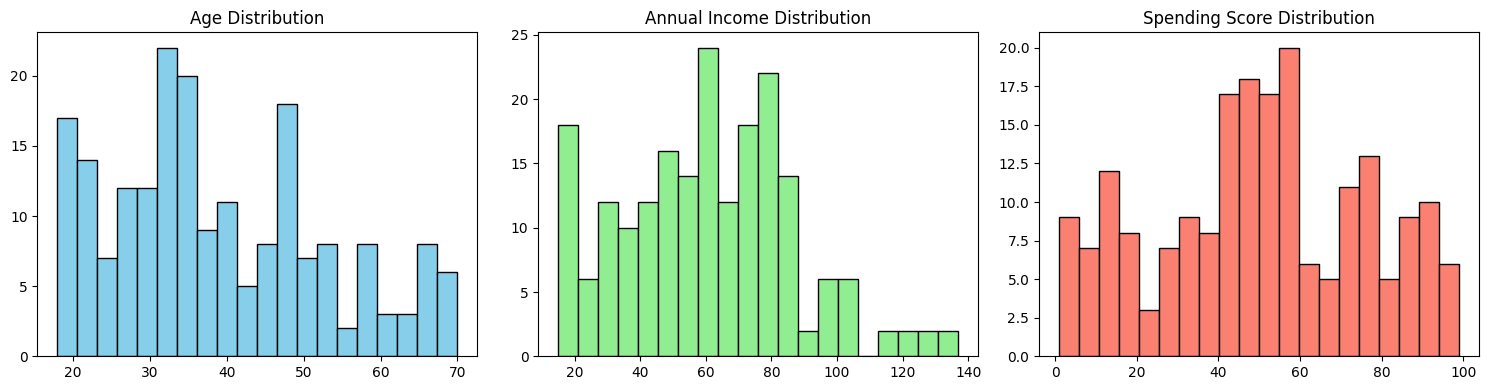

In [4]:
#K-Means Clustering

#Load & Eksplorasi Data

#Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

#Load Dataset
#Dataset: Age, Annual Income (k$), Spending Score (1-100)
# Alternative: create synthetic customer data
# np.random.seed(42)
# n_customers = 200
# age = np.random.normal(40, 12, n_customers).clip(18, 70)
# income = np.random.normal(60, 25, n_customers).clip(15, 140)
# spending_score = np.random.normal(50, 25, n_customers).clip(1, 100)

# df = pd.DataFrame({
#     'CustomerID': range(1, n_customers + 1),
#     'Age': age,
#     'Annual_Income_k$': income,
#     'Spending_Score': spending_score
# })

df = pd.read_csv("Mall_Customers.csv")

print("Dataset Info:")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"\nMissing values: {df.isnull().sum()}")
print("\nStatistical Summary:")
print(df.describe())

#Visualisasi Distribusi Fitur
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].hist(df['Age'], bins = 20, color='skyblue', edgecolor='black') #bins = jumlah bar dalam histogram/data dibagi ke berapa kelompok, edgecolor = warna garis tepi
axes[0].set_title('Age Distribution')
axes[1].hist(df['Annual Income (k$)'], bins = 20, color='lightgreen', edgecolor='black')
axes[1].set_title('Annual Income Distribution')
axes[2].hist(df['Spending Score (1-100)'], bins = 20, color='salmon', edgecolor='black')
axes[2].set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

Before Scaling:
Mean: [60.56 50.2 ]
Std: [26.19897708 25.75888196]

After scaling:
Mean: [-2.13162821e-16 -1.46549439e-16]
Std: [1. 1.]


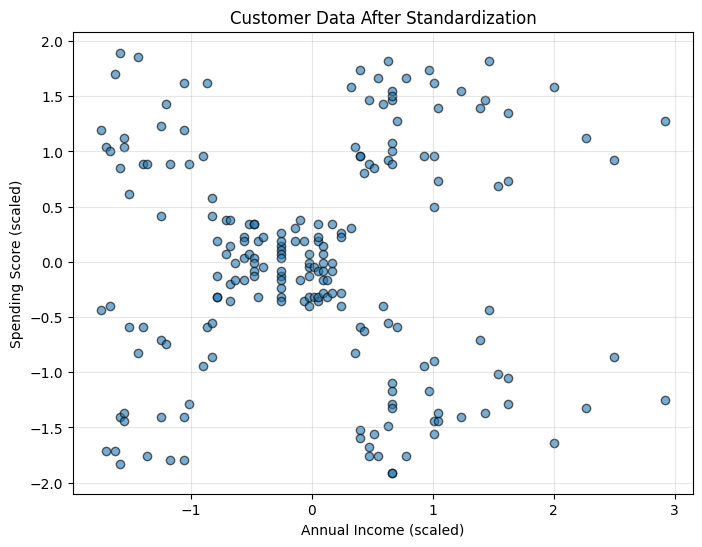

In [12]:
#Pilih Fitur untuk Clustering
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features].values

#Scaling Data (Wajib untuk K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before Scaling:")
print(f"Mean: {X.mean(axis=0)}")
print(f"Std: {X.std(axis=0)}")
print("\nAfter scaling:")
print(f"Mean: {X_scaled.mean(axis=0)}")
print(f"Std: {X_scaled.std(axis=0)}") #Menantukan axis bisa dari melihat shape

#Visualiasikan Data Setelah Scaling
plt.figure(figsize=(8,6))
plt.scatter(X_scaled[:, 0], X_scaled[: , 1], alpha=0.6, edgecolors='k')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.title('Customer Data After Standardization')
plt.grid(alpha=0.3)
plt.show()

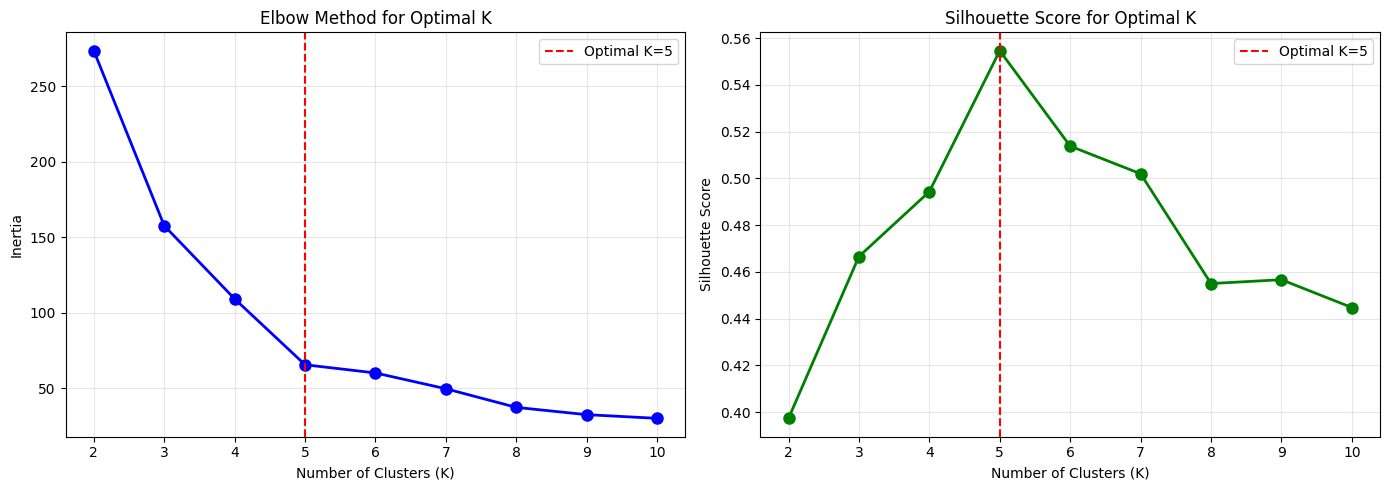

Recommended K from Elbow: 5
Best Silhouette Score at K-5: 0.555


In [13]:
#Elbow Method & Silhouette Score untuk Menentukan Jumlah Cluster Optimal
#Elbow Method (Inertia)
inertias = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

#Plot Elbow Method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal K')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Recommended K from Elbow: 5")
print(f"Best Silhouette Score at K-5: {silhouette_scores[3]:.3f}")


K-Means Clustering Results:

 Cluster Centers (in original scaled):
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Cluster Sizes:
Cluster KMeans
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

Cluster Summary:
               Annual Income (k$)                  Spending Score (1-100)  \
                             mean        std count                   mean   
Cluster KMeans                                                              
0                       55.296296   8.988109    81              49.518519   
1                       86.538462  16.312485    39              82.128205   
2                       25.727273   7.566731    22              79.3

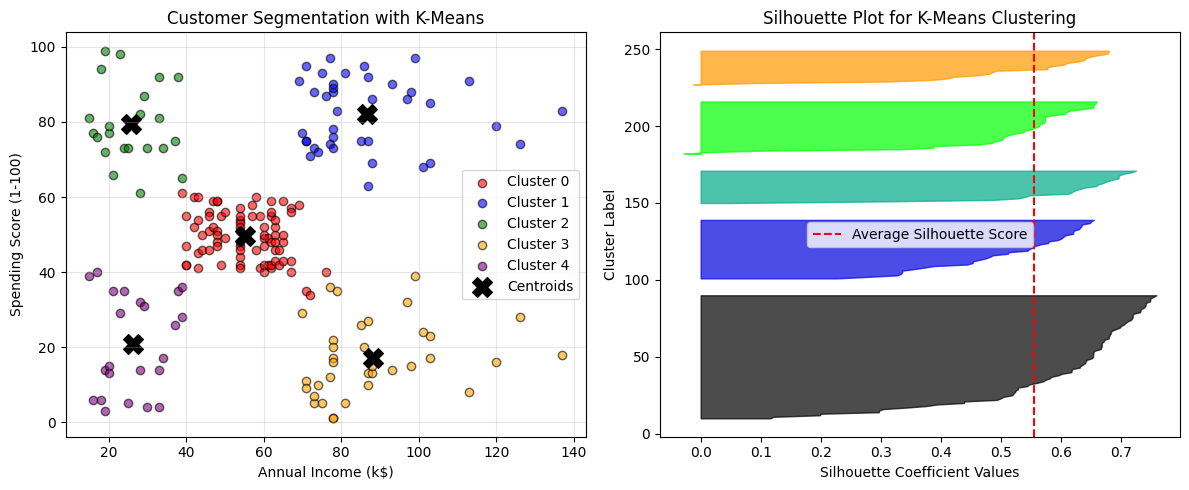


Interpretation of Clusters:
Cluster 0: Medium Income - Medium Spenders (Kelas Menengah) - Pelanggan yang memiliki pendapatan dan kebiasaan belanja rata-rata | Size: 81 customers (40.5%)
Cluster 1: High Income - High Spenders (Premium/VVIP) - Pelanggan dengan pendapatan tinggi dan kebiasaan belanja yang tinggi | Size: 39 customers (19.5%)
Cluster 2: Low Income - High Spenders (Borongan/Budak Promo) - Pelanggan dengan pendapatan rendah tetapi kebiasaan belanja yang tinggi | Size: 22 customers (11.0%)
Cluster 3: High Income - Low Spenders (Hemat) - Mungkin pelanggan yang lebih tua atau lebih muda dengan pendapatan tinggi tetapi tidak terlalu sering berbelanja | Size: 35 customers (17.5%)
Cluster 4: Low Income - Low Spenders (Terbatas) - Pelanggan dengan pendapatan rendah dan kebiasaan belanja yang terbatas | Size: 23 customers (11.5%)


In [17]:
#Implementasi K-Means dengan K Optimal
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster KMeans'] = kmeans.fit_predict(X_scaled)

#Analisis hasil clustering
print("K-Means Clustering Results:")
print("\n Cluster Centers (in original scaled):")
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df.index.name = 'Cluster'
print(centers_df)

print("\nCluster Sizes:")
print(df['Cluster KMeans'].value_counts().sort_index())

#Analisis Karakteristik Setiap Cluster
cluster_summary = df.groupby('Cluster KMeans')[features].agg(['mean', 'std', 'count'])
print("\nCluster Summary:")
print(cluster_summary)

#Visualisasi Cluster
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green', 'orange', 'purple']
for cluster in range(5):
    cluster_data = df[df['Cluster KMeans'] == cluster]
    plt.scatter(cluster_data['Annual Income (k$)'],
                cluster_data['Spending Score (1-100)'],
                c=colors[cluster], label=f"Cluster {cluster}",
                alpha=0.6, edgecolors='k')
plt.scatter(centers_original[:,0], centers_original[:,1],
            c='black', marker='X', s=200, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segmentation with K-Means')
plt.legend()
plt.grid(alpha=0.3)

#Silhouette Plot
plt.subplot(1, 2, 2)
silhouette_vals = silhouette_samples(X_scaled, df['Cluster KMeans'])
y_lower = 10
for i in range(5):
    cluster_silhouette = silhouette_vals[df['Cluster KMeans'] == i]
    cluster_silhouette.sort()
    size_cluster = len(cluster_silhouette)
    y_upper = y_lower + size_cluster
    color = plt.cm.nipy_spectral(float(i) / 5)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette,
                      facecolor = color, edgecolor=color, alpha=0.7)
    y_lower = y_upper + 10

plt.axvline(x=silhouette_score(X_scaled, df['Cluster KMeans']),
            color='red', linestyle='--', label='Average Silhouette Score')
plt.xlabel('Silhouette Coefficient Values')
plt.ylabel('Cluster Label')
plt.title('Silhouette Plot for K-Means Clustering')
plt.legend()
plt.tight_layout()
plt.show()

#Interpretasi segmentasi
print("\nInterpretation of Clusters:")
interpretation = {
    0: "Medium Income - Medium Spenders (Kelas Menengah) - Pelanggan yang memiliki pendapatan dan kebiasaan belanja rata-rata",
    1: "High Income - High Spenders (Premium/VVIP) - Pelanggan dengan pendapatan tinggi dan kebiasaan belanja yang tinggi",
    2: "Low Income - High Spenders (Borongan/Budak Promo) - Pelanggan dengan pendapatan rendah tetapi kebiasaan belanja yang tinggi",
    3: "High Income - Low Spenders (Hemat) - Mungkin pelanggan yang lebih tua atau lebih muda dengan pendapatan tinggi tetapi tidak terlalu sering berbelanja",
    4: "Low Income - Low Spenders (Terbatas) - Pelanggan dengan pendapatan rendah dan kebiasaan belanja yang terbatas",
}

for cluster, label in interpretation.items():
    size = df[df['Cluster KMeans'] == cluster].shape[0]
    print(f"Cluster {cluster}: {label} | Size: {size} customers ({size/len(df)*100:.1f}%)")

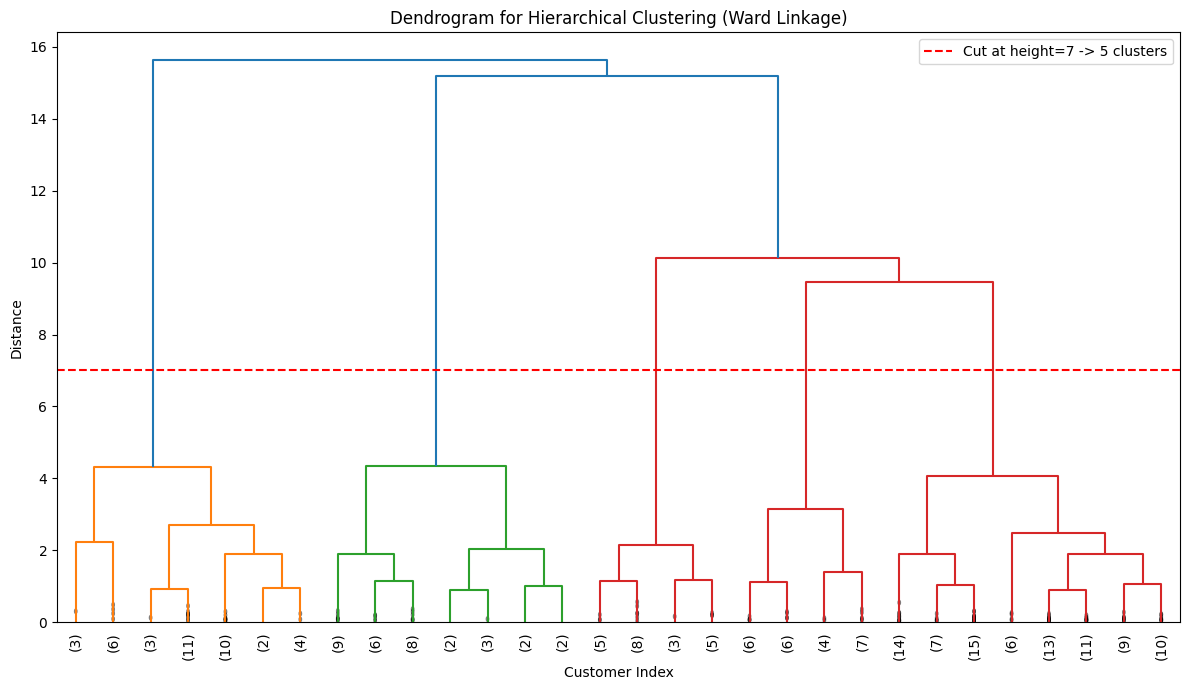

Adjusted Rand Index between K-Means and Hierarchical Clustering: 0.942
Interpretasi: ARI > 0.7 menunjukkan kesepakatan yang kuat antara kedua metode clustering, sementara ARI < 0.5 menunjukkan kesepakatan yang lemah.


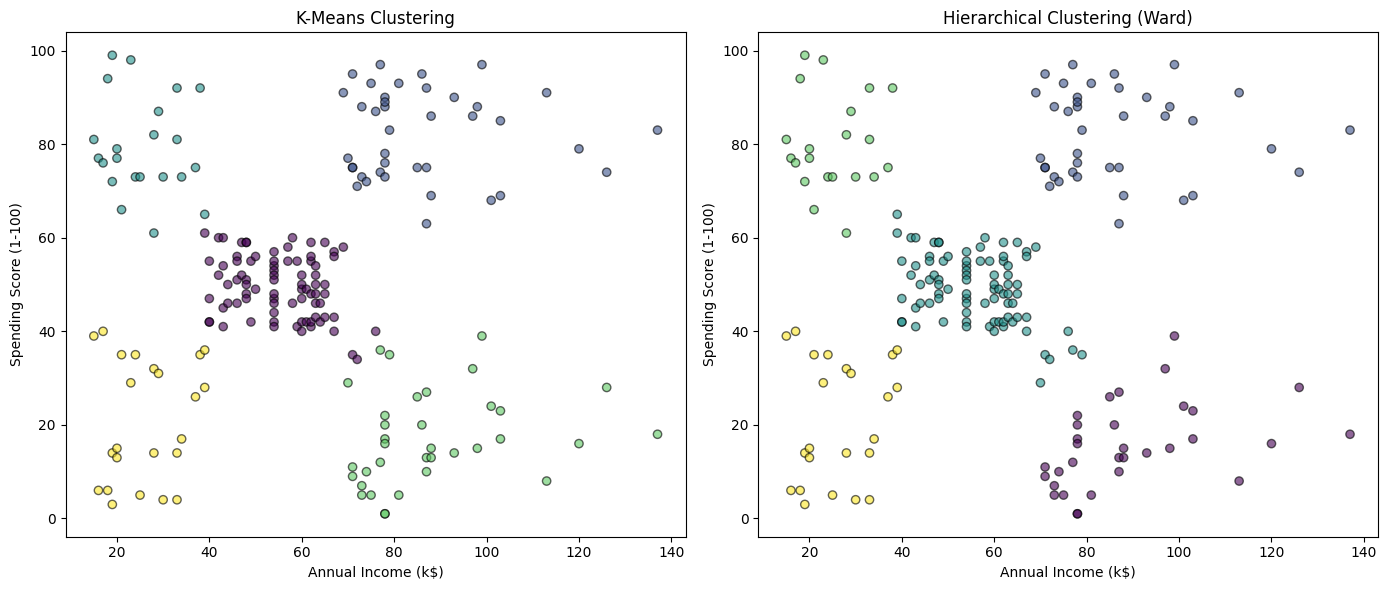

In [18]:
#Hierarchical Clustering
#Hierarchical Clustering dengan Ward Linkage
hc = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Cluster Hierarchical'] = hc.fit_predict(X_scaled)

#Dendrogram untuk Hierarchical Clustering
plt.figure(figsize=(12, 7))
linkage_matrix = linkage(X_scaled, method='ward')

#Plot dendrogram
from scipy.cluster.hierarchy import dendrogram
dendrogram(linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90.,
           leaf_font_size=10., show_contracted=True)
plt.axhline(y=7, color='r', linestyle='--', label='Cut at height=7 -> 5 clusters')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.title('Dendrogram for Hierarchical Clustering (Ward Linkage)')
plt.legend()
plt.tight_layout()
plt.show()

#Compre with K-Means
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(df['Cluster KMeans'], df['Cluster Hierarchical'])
print(f"Adjusted Rand Index between K-Means and Hierarchical Clustering: {ari:.3f}")
print("Interpretasi: ARI > 0.7 menunjukkan kesepakatan yang kuat antara kedua metode clustering, sementara ARI < 0.5 menunjukkan kesepakatan yang lemah.")

#Visual Comparison of Clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                c=df['Cluster KMeans'], cmap='viridis', alpha=0.6, edgecolors='k')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('K-Means Clustering')

axes[1].scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                c=df['Cluster Hierarchical'], cmap='viridis', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('Annual Income (k$)')
axes[1].set_ylabel('Spending Score (1-100)')
axes[1].set_title('Hierarchical Clustering (Ward)')

plt.tight_layout()
plt.show()

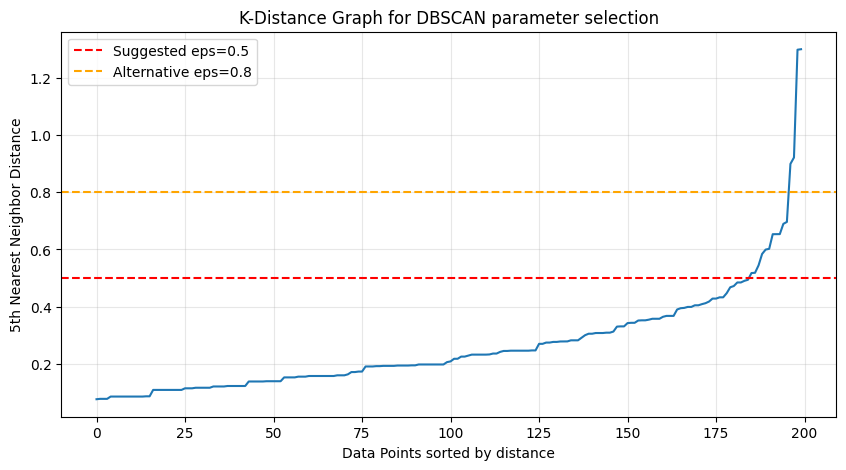

DBSCAN Clustering Results with Different Parameters:
   eps  min_samples  n_clusters  n_noise  silhouette_score
0  0.3            3           9       14          0.413619
5  0.5           10           4       21          0.406405
3  0.5            3           2        7          0.356602
4  0.5            5           2        8          0.350446
1  0.3            5           7       35          0.316141
2  0.3           10           4       88          0.140885
6  0.8            3           1        0         -1.000000
7  0.8            5           1        0         -1.000000
8  0.8           10           1        4         -1.000000
9  1.0            3           1        0         -1.000000

BEST DBSCAN MODEL
eps: 0.3
min_samples: 3.0
Number of clusters: 10
Number of noise points: 14
Silhouette Score: 0.414


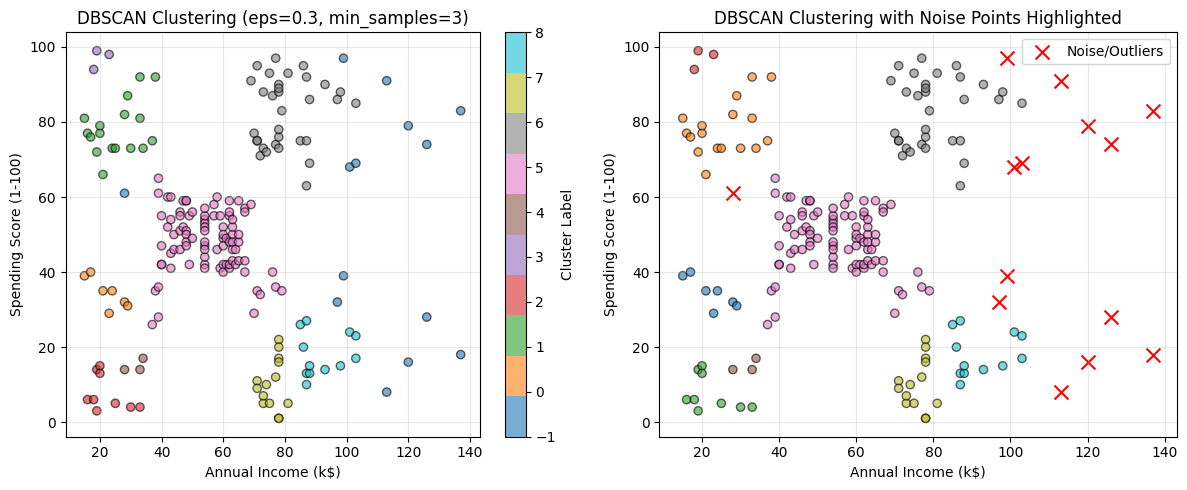

In [21]:
#DBSCAN Clustering
#Cari parameter eps yang optimal
from sklearn.neighbors import NearestNeighbors

#K-distance graph untuk menentukan eps
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 4], axis=0) #jarak ke tetangga ke-5 untuk setiap titik data
plt.figure(figsize=(10, 5))
plt.plot(distances)
plt.xlabel('Data Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Graph for DBSCAN parameter selection')
plt.axhline(y=0.5, color='r', linestyle='--', label='Suggested eps=0.5')
plt.axhline(y=0.8, color='orange', linestyle='--', label='Alternative eps=0.8')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#DBSCAN dengan berbagai parameter
eps_values = [0.3, 0.5, 0.8, 1.0]
min_samples_values = [3, 5, 10]

results_dbscan = []

for eps in eps_values:
    for min_samples in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            sil_score = silhouette_score(X_scaled, labels)
        else: sil_score = -1  # Tidak valid jika hanya ada 1 cluster

        results_dbscan.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': sil_score
        })

results_df = pd.DataFrame(results_dbscan)
print("DBSCAN Clustering Results with Different Parameters:")
print(results_df.sort_values(by='silhouette_score', ascending=False).head(10))

#Best DBSCAN model
best_params = results_df.loc[results_df['silhouette_score'].idxmax()]
dbscan = DBSCAN(eps=best_params['eps'], min_samples=int(best_params['min_samples']))
df['Cluster DBSCAN'] = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(df['Cluster DBSCAN'])) - (1 if -1 in df['Cluster DBSCAN'] else 0)
n_noise_dbscan = (df['Cluster DBSCAN'] == -1).sum()

print(f"\nBEST DBSCAN MODEL")
print(f"eps: {best_params['eps']}")
print(f"min_samples: {best_params['min_samples']}")
print(f"Number of clusters: {n_clusters_dbscan}")
print(f"Number of noise points: {n_noise_dbscan}")
print(f"Silhouette Score: {best_params['silhouette_score']:.3f}")

#Visualisasi DBSCAN Clusters
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                      c=df['Cluster DBSCAN'], cmap='tab10', alpha=0.6, edgecolors='k')
plt.colorbar(scatter, label='Cluster Label')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'DBSCAN Clustering (eps={best_params["eps"]}, min_samples={int(best_params["min_samples"])})')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
#Highlight noise points
normal_points = df[df['Cluster DBSCAN'] != -1]
noise_points = df[df['Cluster DBSCAN'] == -1]

plt.scatter(normal_points['Annual Income (k$)'], normal_points['Spending Score (1-100)'],
            c=normal_points['Cluster DBSCAN'], cmap='tab10', alpha=0.6, edgecolors='k')
plt.scatter(noise_points['Annual Income (k$)'], noise_points['Spending Score (1-100)'],
            c='red', marker='x', s=100, label='Noise/Outliers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clustering with Noise Points Highlighted')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Clustering algorithms comparison

Metrics Comparison (better silhouette score, lower Davies-Bouldin score):
K-Means: Silhouette Score = 0.555, Davies-Bouldin Score = 0.572, Clusters = 5
Hierarchical (Ward): Silhouette Score = 0.554, Davies-Bouldin Score = 0.578, Clusters = 5
DBSCAN: Silhouette Score = 0.414, Davies-Bouldin Score = 0.851, Clusters = 10


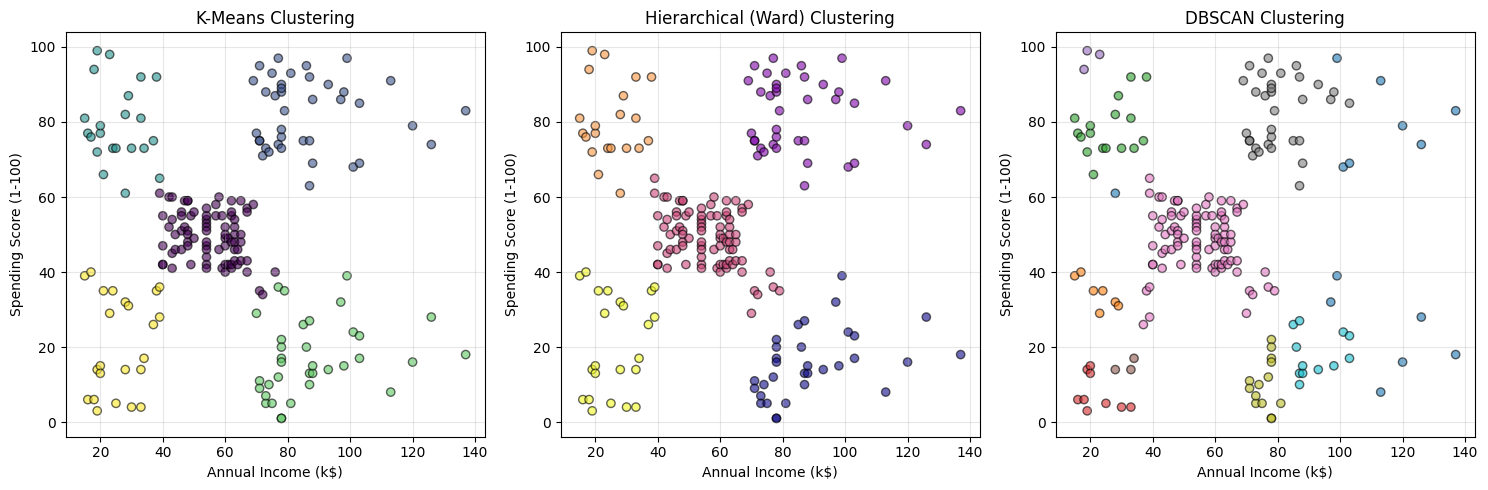


Business Recommendations based on Clustering Results:
Berdasarkan segmentasi yang ditemukan:

High Income - High Spenders (Cluster 1):
  • - Tawarkan produk premium, layanan eksklusif, dan pengalaman belanja yang dipersonalisasi untuk mempertahankan pelanggan ini dan mendorong pembelian berulang.
  • - Gunakan program loyalitas yang memberikan penghargaan atas pembelian mereka dan akses ke penawaran khusus.
  • - Fokus pada pemasaran yang menyoroti kualitas, status, dan nilai eksklusif dari produk untuk menarik pelanggan ini.

Low Income - High Spenders (Cluster 2):
  • - Tawarkan diskon khusus, paket bundling, atau program cicilan untuk menarik pelanggan ini agar tetap berbelanja tanpa merasa terbebani secara finansial.
  • - Fokus pada penawaran yang memberikan nilai tinggi dengan harga terjangkau untuk menarik pelanggan ini agar tetap berbelanja.
  • - Gunakan kampanye pemasaran yang menyoroti nilai dan kualitas produk untuk menarik pelanggan ini agar meningkatkan frekuensi belanja

In [23]:
#Perbandingan dan Evaluasi
from sklearn.metrics import davies_bouldin_score

algorithms ={
    'K-Means' : df['Cluster KMeans'],
    'Hierarchical (Ward)' : df['Cluster Hierarchical'],
    'DBSCAN' : df['Cluster DBSCAN']
}

print("Clustering algorithms comparison")
print("\nMetrics Comparison (better silhouette score, lower Davies-Bouldin score):")

for name, labels in algorithms.items():
    if len(set(labels)) > 1:
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        n_clusters = len(set(labels))
        print(f"{name}: Silhouette Score = {sil:.3f}, Davies-Bouldin Score = {db:.3f}, Clusters = {n_clusters}")
    else:
        print(f"{name}: Only 1 cluster found, metrics not valid.")

#Visualisasi Perbandingan 3 algoritma
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

methods = [
    ('K-Means', df['Cluster KMeans'], 'viridis'),
    ('Hierarchical (Ward)', df['Cluster Hierarchical'], 'plasma'),
    ('DBSCAN', df['Cluster DBSCAN'], 'tab10')
]

for idx, (name, labels, cmap) in enumerate(methods):
    ax = axes[idx]
    scatter = ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'],
                         c=labels, cmap=cmap, alpha=0.6, edgecolors='k')
    ax.set_xlabel('Annual Income (k$)')
    ax.set_ylabel('Spending Score (1-100)')
    ax.set_title(f"{name} Clustering")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Rekomendasi untuk Bisnis
print("\nBusiness Recommendations based on Clustering Results:")
print("Berdasarkan segmentasi yang ditemukan:")

segment_strategy = {
    f"High Income - High Spenders (Cluster 1)": [
        "- Tawarkan produk premium, layanan eksklusif, dan pengalaman belanja yang dipersonalisasi untuk mempertahankan pelanggan ini dan mendorong pembelian berulang.",
        "- Gunakan program loyalitas yang memberikan penghargaan atas pembelian mereka dan akses ke penawaran khusus.",
        "- Fokus pada pemasaran yang menyoroti kualitas, status, dan nilai eksklusif dari produk untuk menarik pelanggan ini."
    ],
    f"Low Income - High Spenders (Cluster 2)": [
        "- Tawarkan diskon khusus, paket bundling, atau program cicilan untuk menarik pelanggan ini agar tetap berbelanja tanpa merasa terbebani secara finansial.",
        "- Fokus pada penawaran yang memberikan nilai tinggi dengan harga terjangkau untuk menarik pelanggan ini agar tetap berbelanja.",
        "- Gunakan kampanye pemasaran yang menyoroti nilai dan kualitas produk untuk menarik pelanggan ini agar meningkatkan frekuensi belanja mereka."
    ],
    f"Medium Income - Medium Spenders (Cluster 0)": [
        "- Gunakan kampanye pemasaran yang menyoroti nilai dan kualitas produk untuk menarik pelanggan ini agar meningkatkan frekuensi belanja mereka.",
        "- Tawarkan promosi musiman atau diskon khusus untuk mendorong pelanggan ini agar berbelanja lebih sering.",
        "- Fokus pada penawaran yang memberikan nilai tinggi dengan harga terjangkau untuk menarik pelanggan ini agar tetap berbelanja."
    ],
    f"High Income - Low Spenders (Cluster 3)": [
        "- Identifikasi alasan di balik rendahnya kebiasaan belanja dan tawarkan insentif seperti diskon khusus atau program loyalitas untuk mendorong mereka berbelanja lebih sering.",
        "- Fokus pada penawaran yang memberikan nilai tinggi dengan harga terjangkau untuk menarik pelanggan ini agar tetap berbelanja.",
        "- Identifikasi alasan di balik rendahnya kebiasaan belanja dan tawarkan insentif seperti diskon khusus atau program loyalitas untuk mendorong mereka berbelanja lebih sering."
    ],
    f"Low Income - Low Spenders (Cluster 4)": [
        "- Fokus pada penawaran yang sangat terjangkau, promosi diskon besar, dan kampanye pemasaran yang menekankan nilai untuk menarik pelanggan ini agar mulai berbelanja.",
        "- Tawarkan produk dengan harga rendah atau paket bundling untuk menarik pelanggan ini agar mulai berbelanja.",
        "- Fokus pada penawaran yang sangat terjangkau, promosi diskon besar, dan kampanye pemasaran yang menekankan nilai untuk menarik pelanggan ini agar mulai berbelanja."
    ]
}

for segment, strategy in segment_strategy.items():
    print(f"\n{segment}:")
    for s in strategy:
        print(f"  • {s}")

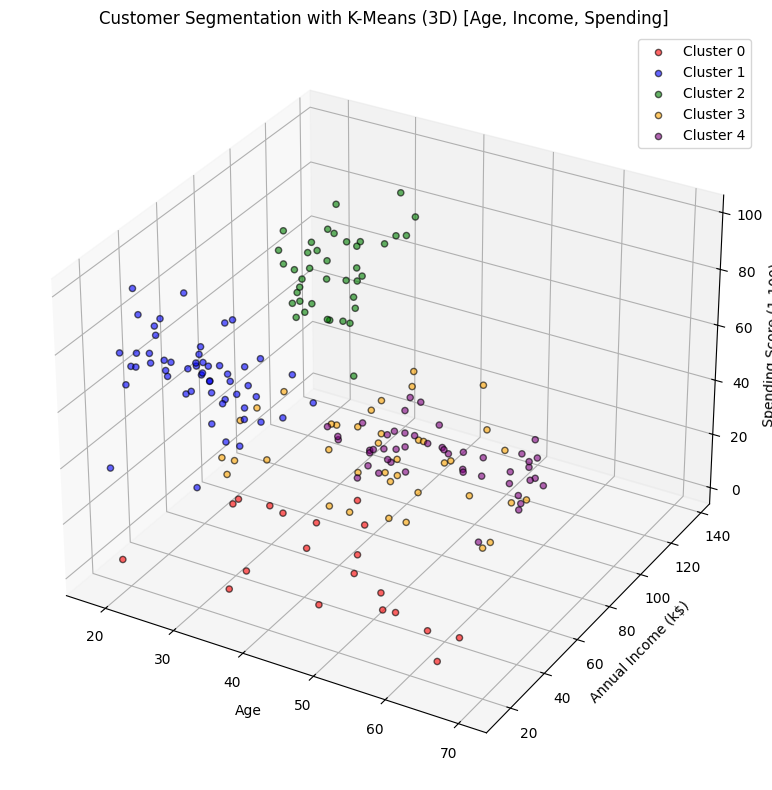


Additional Insights with 3D Clustering:
Counter untuk setiap cluster: Cluster 3D
4    47
3    39
2    40
1    54
0    20
Name: count, dtype: int64
                  Age  Annual Income (k$)  Spending Score (1-100)
Cluster 3D                                                       
0           46.250000           26.750000               18.350000
1           25.185185           41.092593               62.240741
2           32.875000           86.100000               81.525000
3           39.871795           86.102564               19.358974
4           55.638298           54.382979               48.851064


In [36]:
#Studi Kasus - Segmentasi Pelanggan Multi-Dimensi
features_3d = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X_3d = df[features_3d].values
X_3d_scaled = scaler.fit_transform(X_3d)

#K-Means Clustering dengan 3 fitur
kmeans_3d = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster 3D'] = kmeans_3d.fit_predict(X_3d_scaled)

#3D Visualization
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

colors_3d = ['red', 'blue', 'green', 'orange', 'purple']
for cluster in range(5):
    cluster_data = df[df['Cluster 3D'] == cluster]
    ax.scatter(cluster_data['Age'],
               cluster_data['Annual Income (k$)'],
               cluster_data['Spending Score (1-100)'],
               c=colors_3d[cluster], label=f"Cluster {cluster}",
               alpha=0.6, edgecolors='k')

ax.set_xlabel('Age')
ax.set_ylabel('Annual Income (k$)')
ax.set_zlabel('Spending Score (1-100)')
ax.set_title('Customer Segmentation with K-Means (3D) [Age, Income, Spending]')
ax.legend()
plt.tight_layout()
plt.show()

#Insight tambahan dengan 3 dimensi
print("\nAdditional Insights with 3D Clustering:")
print(f"Counter untuk setiap cluster: {df['Cluster 3D'].value_counts().sort_index(ascending=False)}")
print(df.groupby('Cluster 3D')[features_3d].mean())

In [33]:
#Mencoba menggunakan model untuk prediksi dengan data baru
data_baru = np.array([[30, 70, 80]]) # Contoh data baru: Age=30, Annual Income=70k$, Spending Score=80
data_baru_scaled = scaler.transform(data_baru) # Jangan lupa untuk scaling data baru sebelum prediksi
predicted_cluster = kmeans_3d.predict(data_baru_scaled)[0]
print(f"Data baru: Age=30, Annual Income=70k$, Spending Score=80")
print(f"Prediksi cluster untuk data baru: Cluster {predicted_cluster}")

Data baru: Age=30, Annual Income=70k$, Spending Score=80
Prediksi cluster untuk data baru: Cluster 2


array([[-0.6351352 ,  0.36031941,  1.15688251]])

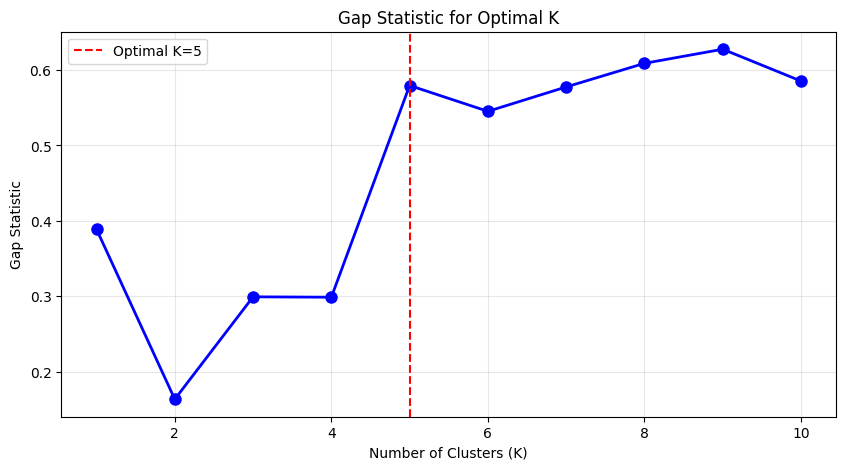

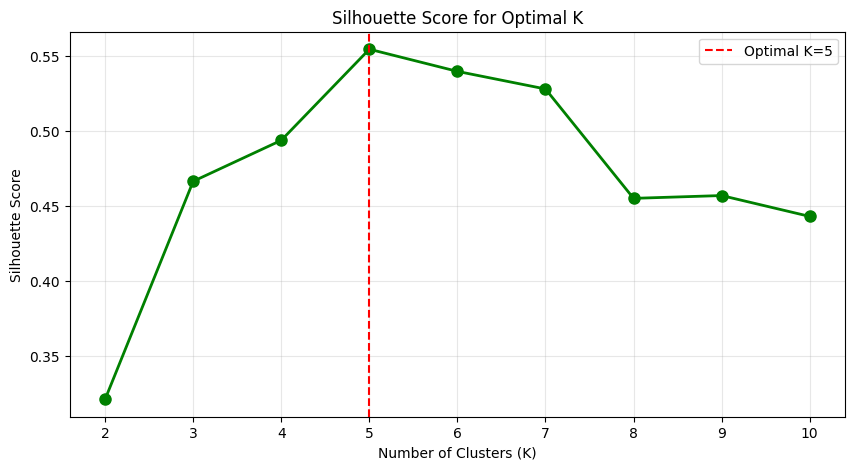


Pairwise Distances between data points (sample):
[[0.         1.63050555 1.28167999 1.47571302 0.08564307]
 [1.63050555 0.         2.91186723 0.15990848 1.59351358]
 [1.28167999 2.91186723 0.         2.75633081 1.32048483]
 [1.47571302 0.15990848 2.75633081 0.         1.4369048 ]
 [0.08564307 1.59351358 1.32048483 1.4369048  0.        ]]


In [40]:
#Optimal K dengan Gap Statistic
from sklearn.metrics import pairwise_distances

def gap_statistic(X, k_max=10, n_refs=5):
    shape = X.shape
    gap_values = np.zeros(k_max)
    mins_sample = X.min(axis=0)
    maxs_sample = X.max(axis=0)
    # Generate reference datasets
    reference_inertia = np.zeros((n_refs, k_max))
    for i in range(n_refs):
        # random_reference = np.random.random_sample(size=shape) #random_sample = generate random numbers between 0 and 1, mirip 
        #Alternatif pengacakan dengan uniform distribution dalam rentang data asli
        random_reference = np.random.uniform(mins_sample, maxs_sample, size=shape)
        for k in range(1, k_max + 1):
            km = KMeans(n_clusters=k, random_state=42, n_init=10)
            km.fit(random_reference)
            reference_inertia[i, k-1] = km.inertia_

    # Compute inertia for original data
    original_inertia = np.zeros(k_max)
    for k in range(1, k_max + 1):
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        km.fit(X)
        original_inertia[k-1] = km.inertia_

    # Compute gap statistic
    for k in range(1, k_max + 1):
        gap_values[k-1] = np.log(np.mean(reference_inertia[:, k-1])) - np.log(original_inertia[k-1])

    return gap_values

gap_values = gap_statistic(X_scaled, k_max=10, n_refs=5)
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), gap_values, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Gap Statistic')
plt.title('Gap Statistic for Optimal K')
plt.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#Optimal K dengan Silhouette Analysis
silhouette_scores_k = []
K_range_k = range(2, 11)
for k in K_range_k:
    kmeans_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = kmeans_k.fit_predict(X_scaled)
    silhouette_scores_k.append(silhouette_score(X_scaled, labels_k))
plt.figure(figsize=(10, 5))
plt.plot(K_range_k, silhouette_scores_k, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K')
plt.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#Penggunaan Pairwise Distances untuk Evaluasi Cluster

#Hitung jarak rata-rata antar cluster
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
labels_final = kmeans_final.fit_predict(X_scaled)
pairwise_dist = pairwise_distances(X_scaled)
print("\nPairwise Distances between data points (sample):")
print(pairwise_dist[:5, :5]) # Tampilkan jarak untuk 5 data pertama




Dataset Info:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185

Shape: (440, 8)

Missing values: Channel             0
Region              0
Fresh               0
Milk                0
Grocery             0
Frozen              0
Detergents_Paper    0
Delicassen          0
dtype: int64

Statistical Summary:
          Channel      Region          Fresh          Milk       Grocery  \
count  440.000000  440.000000     440.000000    440.000000    440.000000   
mean     1.322727    2.543182   12000.297727   5796.265909   7951.277273   
std      0.468052    0.774272   12647.3

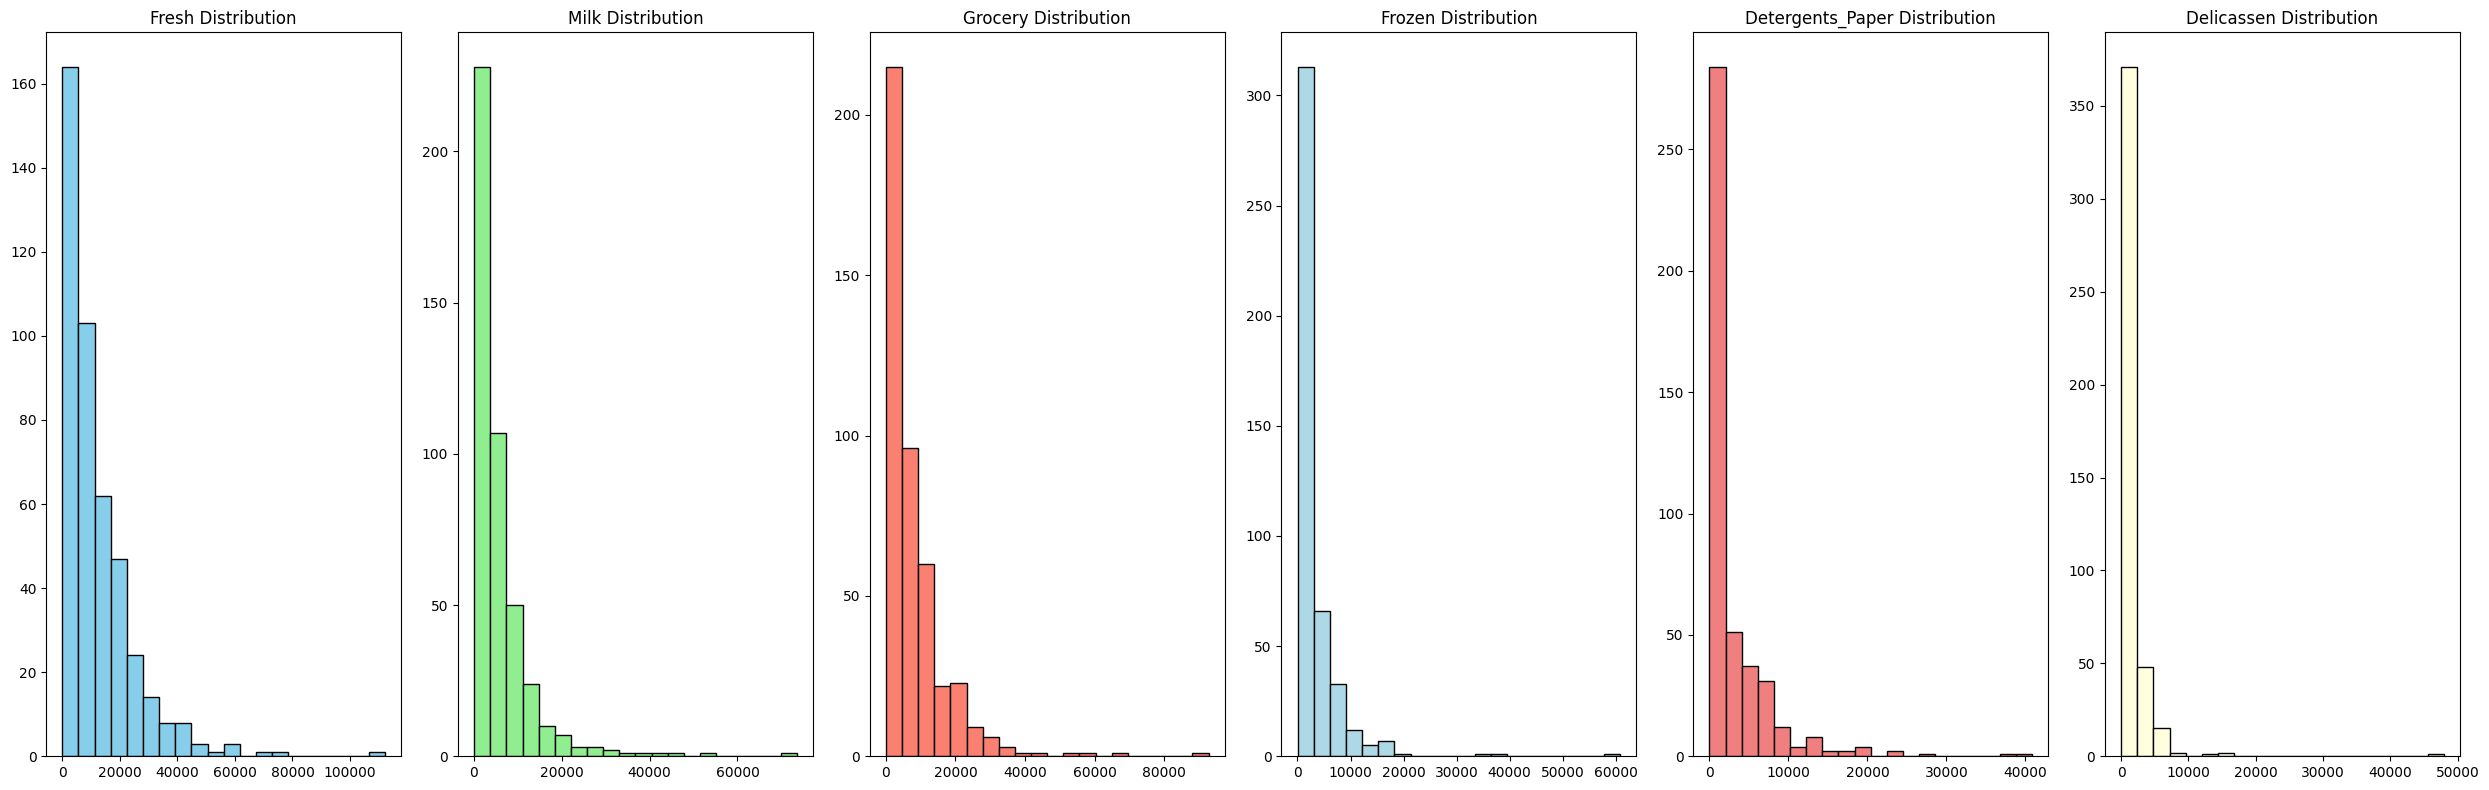

In [48]:
#Clustering dengan dataset baru (Wholesale Customers)

#Load & Eksplorasi Data

#Import Library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

#Load Dataset

new_df = pd.read_csv("Wholesale customers data.csv")

print("Dataset Info:")
print(new_df.head())
print(f"\nShape: {new_df.shape}")
print(f"\nMissing values: {new_df.isnull().sum()}")
print("\nStatistical Summary:")
print(new_df.describe())

#Visualisasi Distribusi Fitur
fig, axes = plt.subplots(1, 6, figsize=(25, 8))
axes[0].hist(new_df['Fresh'], bins = 20, color='skyblue', edgecolor='black') #bins = jumlah bar dalam histogram/data dibagi ke berapa kelompok, edgecolor = warna garis tepi
axes[0].set_title('Fresh Distribution')
axes[1].hist(new_df['Milk'], bins = 20, color='lightgreen', edgecolor='black')
axes[1].set_title('Milk Distribution')
axes[2].hist(new_df['Grocery'], bins = 20, color='salmon', edgecolor='black')
axes[2].set_title('Grocery Distribution')
axes[3].hist(new_df['Frozen'], bins = 20, color='lightblue', edgecolor='black')
axes[3].set_title('Frozen Distribution')
axes[4].hist(new_df['Detergents_Paper'], bins = 20, color='lightcoral', edgecolor='black')
axes[4].set_title('Detergents_Paper Distribution')
axes[5].hist(new_df['Delicassen'], bins = 20, color='lightyellow', edgecolor='black')
axes[5].set_title('Delicassen Distribution')
plt.tight_layout()
plt.show()

Before Scaling:
Mean: [12000.29772727  5796.26590909  7951.27727273  3071.93181818
  2881.49318182  1524.87045455]
Std: [12632.94872528  7371.98561168  9492.35763752  4849.15352031
  4762.43334956  2816.89944863]

After scaling:
Mean: [-3.43159844e-17  0.00000000e+00 -4.03717464e-17  3.63345717e-17
  2.42230478e-17 -8.07434927e-18]
Std: [1. 1. 1. 1. 1. 1.]
Before Scaling:
Mean: [12000.29772727  5796.26590909  7951.27727273  3071.93181818
  2881.49318182  1524.87045455]
Std: [12632.94872528  7371.98561168  9492.35763752  4849.15352031
  4762.43334956  2816.89944863]

After scaling:
Mean: [ 3.22973971e-17 -7.10542736e-16 -1.08196280e-15  2.98750923e-16
 -6.29799243e-16 -2.22044605e-17]
Std: [1. 1. 1. 1. 1. 1.]

Scaled Data Sample:
[[ 0.05293319  0.52356777 -0.04111489 -0.58936716 -0.04356873 -0.06633906]
 [-0.39130197  0.54445767  0.17031835 -0.27013618  0.08640684  0.08915105]
 [-0.44702926  0.40853771 -0.0281571  -0.13753572  0.13323164  2.24329255]
 [ 0.10011141 -0.62401993 -0.3929769

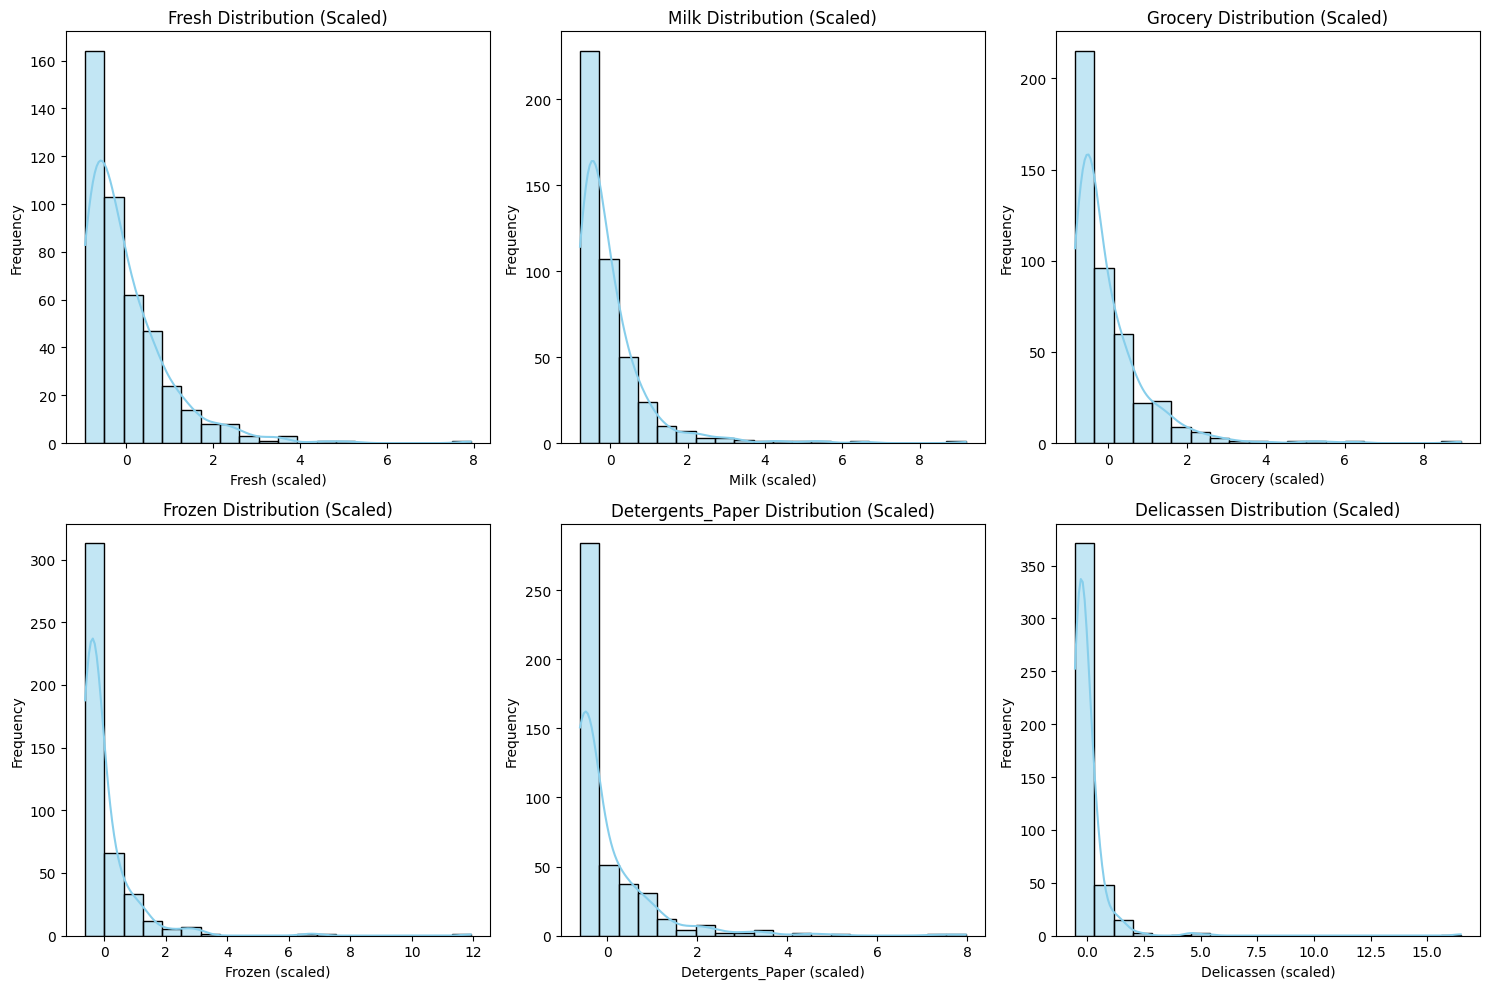

In [82]:
#Pilih Fitur untuk Clustering
features = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen'
]

X_2 = new_df[features].values

#Scaling Data (Wajib untuk K-Means)
scaler = StandardScaler()
X_2_scaled = scaler.fit_transform(X_2)

#New Log Scaling untuk data yang sangat skewed
X_2_log = np.log1p(X_2) #log1p untuk menghindari log(0)
X_2_log_scaled = scaler.fit_transform(X_2_log)

print("Before Scaling:")
print(f"Mean: {X_2.mean(axis=0)}")
print(f"Std: {X_2.std(axis=0)}")
print("\nAfter scaling:")
print(f"Mean: {X_2_scaled.mean(axis=0)}")
print(f"Std: {X_2_scaled.std(axis=0)}") #Menentukan axis bisa dari melihat shape

print("Before Scaling:")
print(f"Mean: {X_2.mean(axis=0)}")
print(f"Std: {X_2.std(axis=0)}")
print("\nAfter scaling:")
print(f"Mean: {X_2_log_scaled.mean(axis=0)}")
print(f"Std: {X_2_log_scaled.std(axis=0)}") #Menentukan axis bisa dari melihat shape

print("\nScaled Data Sample:")
print(X_2_scaled[:5])
print("\nLog-Scaled Data Sample:")
print(X_2_log_scaled[:5])

#Visualiasikan Data Setelah Scaling
# plt.figure(figsize=(8,6))
# plt.scatter(X_2_scaled[:, 0], X_2_scaled[: , 1], alpha=0.6, edgecolors='k')
# plt.xlabel('Annual Income (scaled)')
# plt.ylabel('Spending Score (scaled)')
# plt.title('Customer Data After Standardization')
# plt.grid(alpha=0.3)
# plt.show()

#Visualisasi distribusi fitur setelah scaling
scaled_df = pd.DataFrame(X_2_scaled, columns=features)
plt.figure(figsize=(15, 10))
for i, feature in enumerate(features):
    plt.subplot(2, 3, i+1)
    sns.histplot(scaled_df[feature], bins=20, kde=True, color='skyblue', edgecolor='black')
    plt.title(f'{feature} Distribution (Scaled)')
    plt.xlabel(f'{feature} (scaled)')
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

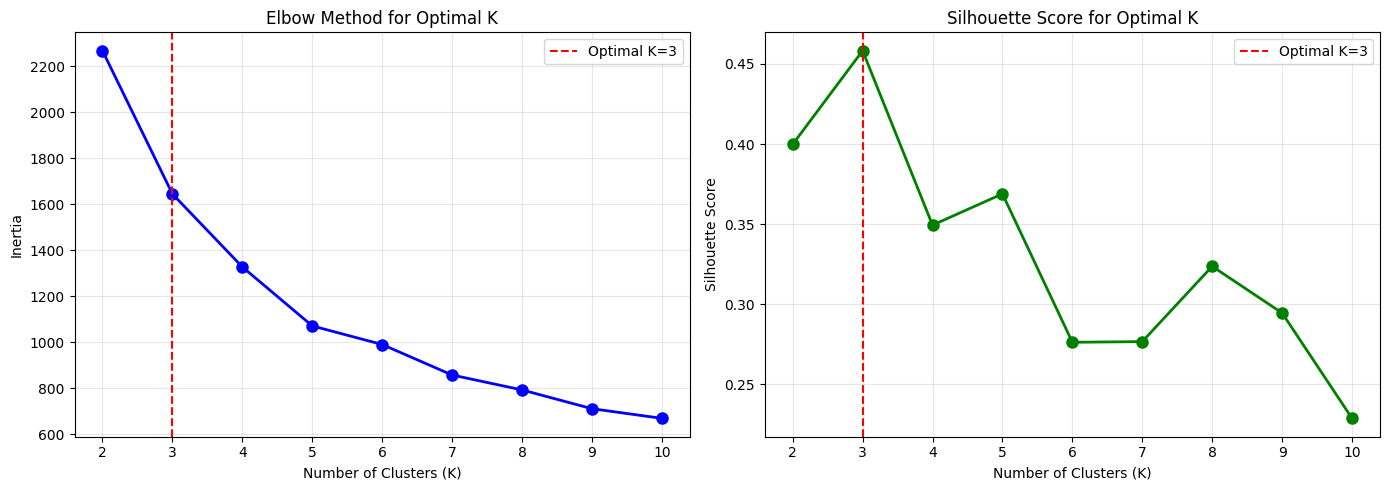

Recommended K from Elbow: 3
Best Silhouette Score at K-3: 0.458


In [83]:
#Elbow Method & Silhouette Score untuk Menentukan Jumlah Cluster Optimal
#Elbow Method (Inertia)
new_inertias = []
new_inertias_log = []
new_silhouette_scores = []
new_silhouette_scores_log = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_2_scaled)
    new_inertias.append(kmeans.inertia_)
    new_silhouette_scores.append(silhouette_score(X_2_scaled, kmeans.labels_))

for k_2 in K_range:
    kmeans = KMeans(n_clusters=k_2, random_state=42)
    kmeans.fit(X_2_log_scaled)
    new_inertias_log.append(kmeans.inertia_)
    new_silhouette_scores_log.append(silhouette_score(X_2_log_scaled, kmeans.labels_))

#Plot Elbow Method
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, new_inertias, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=3, color='red', linestyle='--', label='Optimal K=3')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(K_range, new_silhouette_scores, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=3, color='red', linestyle='--', label='Optimal K=3')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal K')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Recommended K from Elbow: 3")
print(f"Best Silhouette Score at K-3: {new_silhouette_scores[1]:.3f}")


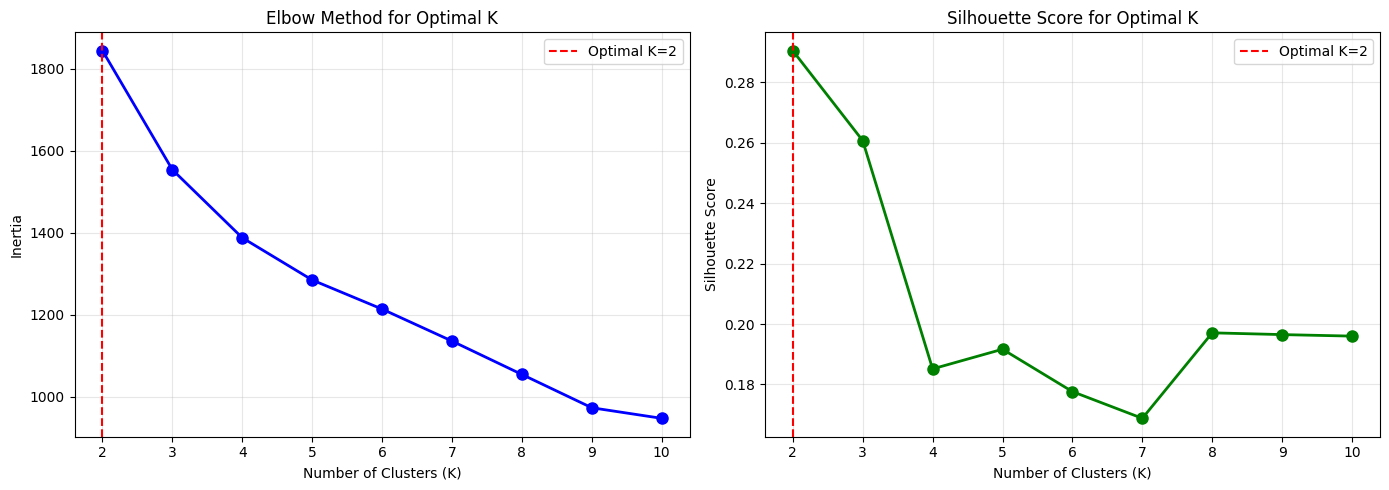

Recommended K from Elbow (Log Transform): 2
Best Silhouette Score at K-2: 0.290


In [87]:
#Plot Elbow Method for Log-Scaled Data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, new_inertias_log, 'bo-', linewidth=2, markersize=8)
ax1.axvline(x=2, color='red', linestyle='--', label='Optimal K=2')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method for Optimal K')
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(K_range, new_silhouette_scores_log, 'go-', linewidth=2, markersize=8)
ax2.axvline(x=2, color='red', linestyle='--', label='Optimal K=2')
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score for Optimal K')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Recommended K from Elbow (Log Transform): 2")
print(f"Best Silhouette Score at K-2: {new_silhouette_scores_log[0]:.3f}")

New K-Means Clustering Results:

 Cluster Centers (in original scaled):
                Fresh          Milk       Grocery        Frozen  \
Cluster                                                           
0        10440.933333  19386.422222  28656.088889   2190.244444   
1        12062.913486   4115.099237   5534.966921   2940.676845   
2        34782.000000  30367.000000  16898.000000  48701.500000   

         Detergents_Paper    Delicassen  
Cluster                                  
0            13327.800000   2374.200000  
1             1696.170483   1299.114504  
2              755.500000  26776.000000  

Cluster Sizes:
Cluster KMeans
0     45
1    393
2      2
Name: count, dtype: int64

Cluster Summary:
                       Fresh                              Milk                \
                        mean           std count          mean           std   
Cluster KMeans                                                                 
0               10440.933333  18154.7254

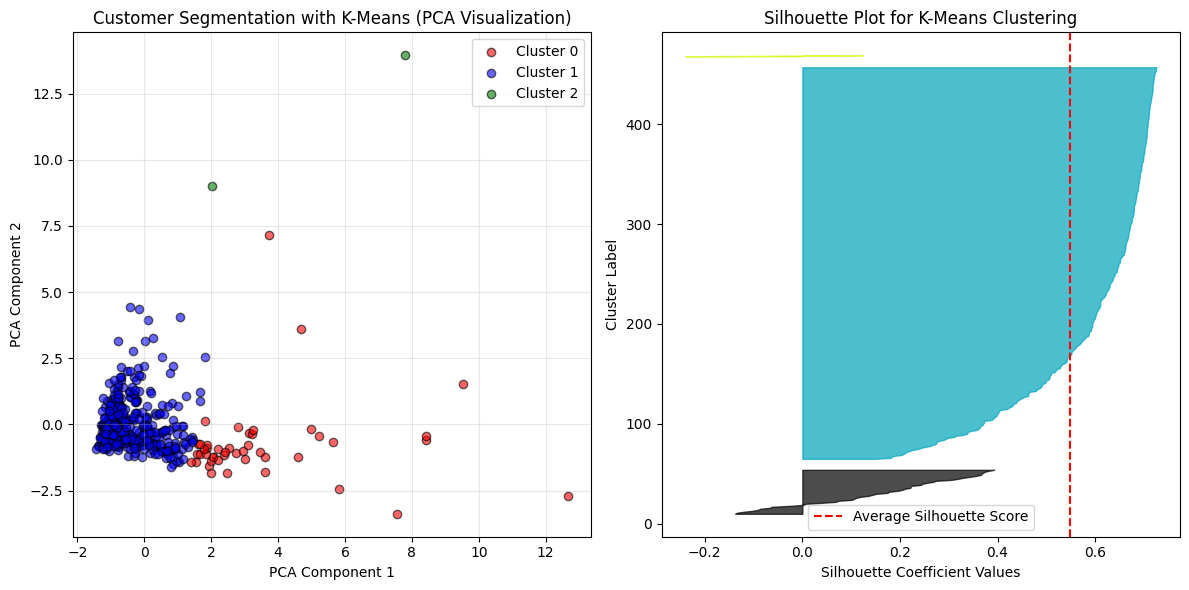


Interpretation of Clusters:
Cluster 0: Cluster 0: Pelanggan dengan pembelian tinggi pada kategori Fresh dan Grocery, mungkin restoran atau bisnis makanan. | Size: 45 customers (10.2%)
Cluster 1: Cluster 1: Pelanggan dengan pembelian tinggi pada kategori Milk dan Detergents_Paper, mungkin supermarket atau toko kelontong. | Size: 393 customers (89.3%)
Cluster 2: Cluster 2: Pelanggan dengan pembelian tinggi pada kategori Frozen dan Delicassen, mungkin bisnis katering atau toko khusus. | Size: 2 customers (0.5%)


In [60]:
#Implementasi K-Means dengan K Optimal
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
new_df['Cluster KMeans'] = kmeans.fit_predict(X_2_scaled)

#Analisis hasil clustering
print("New K-Means Clustering Results:")
print("\n Cluster Centers (in original scaled):")
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df.index.name = 'Cluster'
print(centers_df)

print("\nCluster Sizes:")
print(new_df['Cluster KMeans'].value_counts().sort_index())

#Analisis Karakteristik Setiap Cluster
new_cluster_summary = new_df.groupby('Cluster KMeans')[features].agg(['mean', 'std', 'count'])
print("\nCluster Summary:")
print(new_cluster_summary)

#Visualisasi Cluster
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_2_pca = pca.fit_transform(X_2_scaled)
new_df['PCA1'] = X_2_pca[:, 0]
new_df['PCA2'] = X_2_pca[:, 1]

plt.figure(figsize=(12,6))
plt.subplot(1, 2, 1)
colors = ['red', 'blue', 'green']
for cluster in range(3):
    cluster_data = new_df[new_df['Cluster KMeans'] == cluster]
    plt.scatter(cluster_data['PCA1'], cluster_data['PCA2'],
                c=colors[cluster], label=f"Cluster {cluster}",
                alpha=0.6, edgecolors='k')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segmentation with K-Means (PCA Visualization)')
plt.legend()
plt.grid(alpha=0.3)

# plt.figure(figsize=(12,5))

# plt.subplot(1, 2, 1)
# colors = ['red', 'blue', 'green', 'orange', 'purple']
# for cluster in range(3):
#     cluster_data = new_df[new_df['Cluster KMeans'] == cluster]
#     plt.scatter(cluster_data['Annual Income (k$)'],
#                 cluster_data['Spending Score (1-100)'],
#                 c=colors[cluster], label=f"Cluster {cluster}",
#                 alpha=0.6, edgecolors='k')
# plt.scatter(centers_original[:,0], centers_original[:,1],
#             c='black', marker='X', s=200, label='Centroids')
# plt.xlabel('Annual Income (k$)')
# plt.ylabel('Spending Score (1-100)')
# plt.title('Customer Segmentation with K-Means')
# plt.legend()
# plt.grid(alpha=0.3)

#Silhouette Plot
plt.subplot(1, 2, 2)
silhouette_vals = silhouette_samples(X_2_scaled, new_df['Cluster KMeans'])
y_lower = 10
for i in range(3):
    cluster_silhouette = silhouette_vals[new_df['Cluster KMeans'] == i]
    cluster_silhouette.sort()
    size_cluster = len(cluster_silhouette)
    y_upper = y_lower + size_cluster
    color = plt.cm.nipy_spectral(float(i) / 3)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette,
                      facecolor = color, edgecolor=color, alpha=0.7)
    y_lower = y_upper + 10

plt.axvline(x=silhouette_score(X_2_scaled, new_df['Cluster KMeans']),
            color='red', linestyle='--', label='Average Silhouette Score')
plt.xlabel('Silhouette Coefficient Values')
plt.ylabel('Cluster Label')
plt.title('Silhouette Plot for K-Means Clustering')
plt.legend()
plt.tight_layout()
plt.show()

#Interpretasi segmentasi
print("\nInterpretation of Clusters:")
interpretation = {
    0: "Cluster 0: Pelanggan dengan pembelian tinggi pada kategori Fresh dan Grocery, mungkin restoran atau bisnis makanan.",
    1: "Cluster 1: Pelanggan dengan pembelian tinggi pada kategori Milk dan Detergents_Paper, mungkin supermarket atau toko kelontong.",
    2: "Cluster 2: Pelanggan dengan pembelian tinggi pada kategori Frozen dan Delicassen, mungkin bisnis katering atau toko khusus."
}

for cluster, label in interpretation.items():
    size = new_df[new_df['Cluster KMeans'] == cluster].shape[0]
    print(f"Cluster {cluster}: {label} | Size: {size} customers ({size/len(new_df)*100:.1f}%)")

Cluster KMeans                     0             1             2
Fresh            mean   10440.933333  12062.913486  34782.000000
                 std    18154.725406  11797.674747   2920.351006
                 count     45.000000    393.000000      2.000000
Milk             mean   19386.422222   4115.099237  30367.000000
                 std    13454.171355   3553.286033  19209.262818
                 count     45.000000    393.000000      2.000000
Grocery          mean   28656.088889   5534.966921  16898.000000
                 std    14886.774347   4553.525822   4627.306776
                 count     45.000000    393.000000      2.000000
Frozen           mean    2190.244444   2940.676845  48701.500000
                 std     2822.730047   3743.613850  17207.443520
                 count     45.000000    393.000000      2.000000
Detergents_Paper mean   13327.800000   1696.170483    755.500000
                 std     7888.263291   2124.492000    730.441305
                 count   

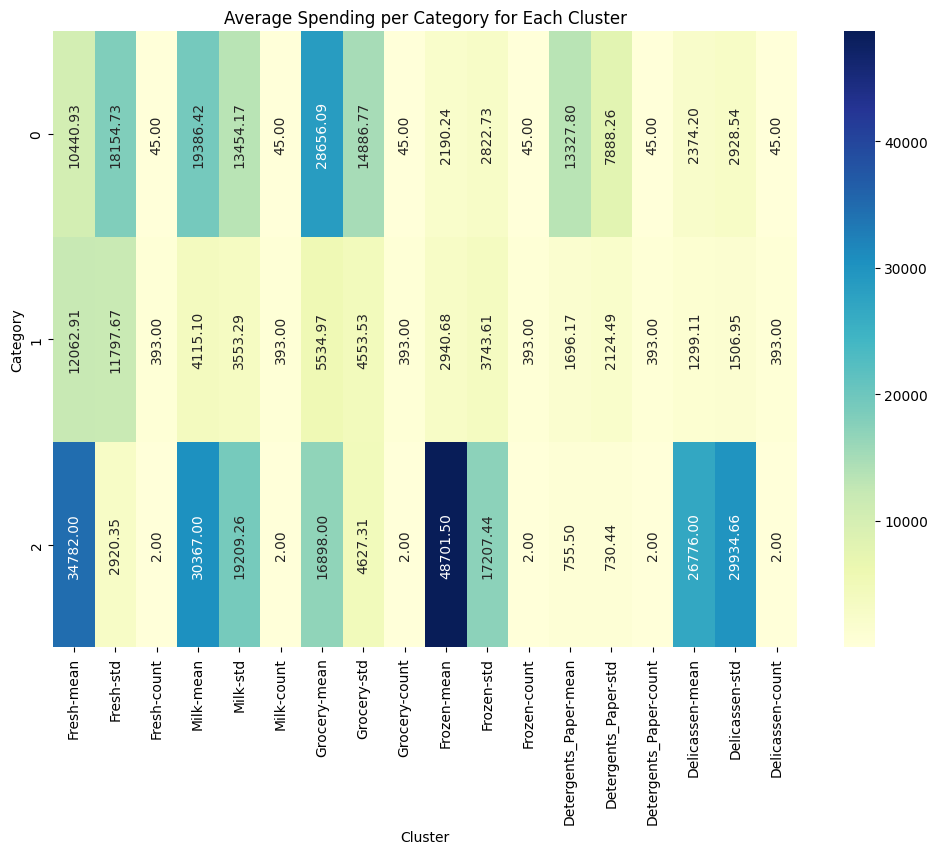

In [71]:
#Visualisasi Heatmap per cluster
print(new_cluster_summary.T)

import seaborn as sns
plt.figure(figsize=(12, 8))
sns.heatmap(new_cluster_summary, annot=True, annot_kws={'rotation': 90, 'va': 'center', 'ha': 'center'}, fmt=".2f", cmap='YlGnBu',)
plt.title('Average Spending per Category for Each Cluster')
plt.xlabel('Cluster')
plt.ylabel('Category')
plt.show()

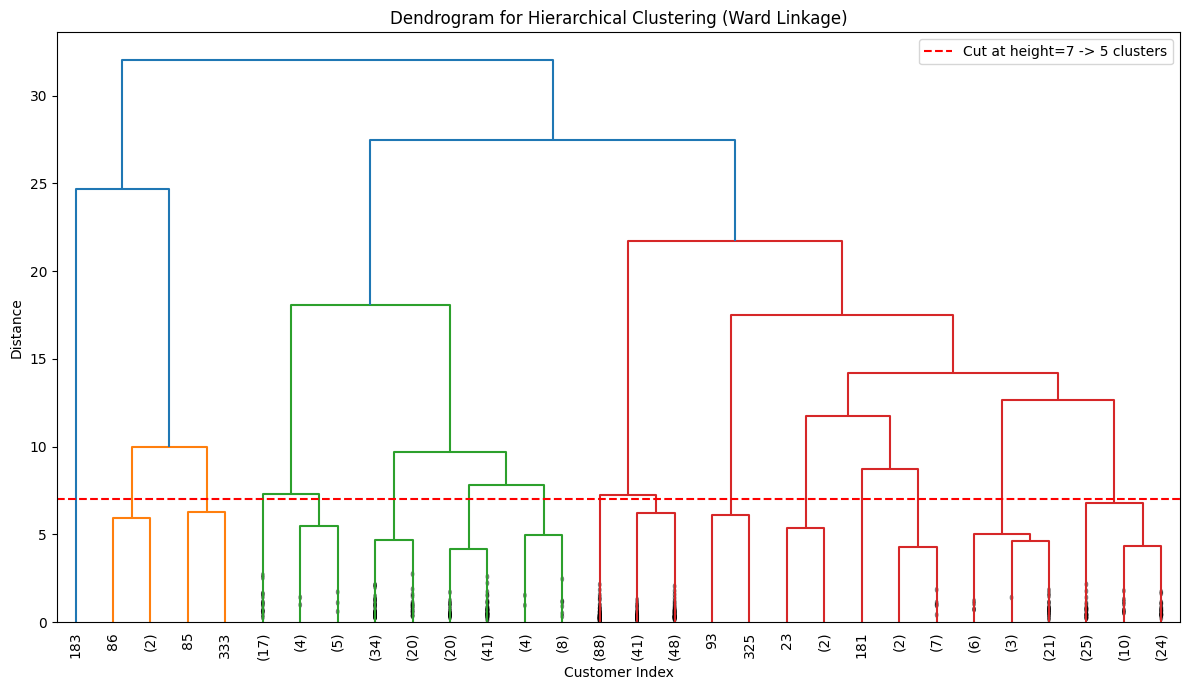

Adjusted Rand Index between K-Means and Hierarchical Clustering: 0.197
Interpretasi: ARI > 0.7 menunjukkan kesepakatan yang kuat antara kedua metode clustering, sementara ARI < 0.5 menunjukkan kesepakatan yang lemah.


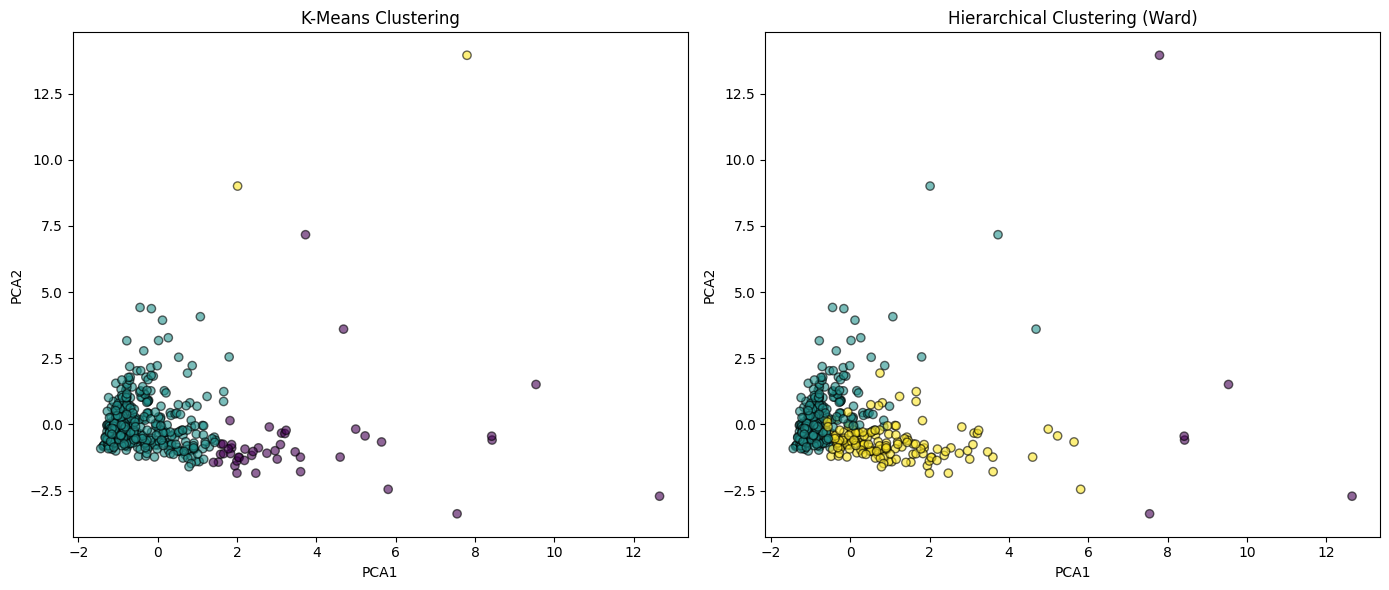

In [76]:
#Hierarchical Clustering
#Hierarchical Clustering dengan Ward Linkage
new_hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
new_df['Cluster Hierarchical'] = new_hc.fit_predict(X_2_scaled)

#Dendrogram untuk Hierarchical Clustering
plt.figure(figsize=(12, 7))
new_linkage_matrix = linkage(X_2_scaled, method='ward')

#Plot dendrogram
from scipy.cluster.hierarchy import dendrogram
dendrogram(new_linkage_matrix, truncate_mode='lastp', p=30, leaf_rotation=90.,
           leaf_font_size=10., show_contracted=True)
plt.axhline(y=7, color='r', linestyle='--', label='Cut at height=7 -> 5 clusters')
plt.xlabel('Customer Index')
plt.ylabel('Distance')
plt.title('Dendrogram for Hierarchical Clustering (Ward Linkage)')
plt.legend()
plt.tight_layout()
plt.show()

#Compre with K-Means
from sklearn.metrics import adjusted_rand_score

new_ari = adjusted_rand_score(new_df['Cluster KMeans'], new_df['Cluster Hierarchical'])
print(f"Adjusted Rand Index between K-Means and Hierarchical Clustering: {new_ari:.3f}")
print("Interpretasi: ARI > 0.7 menunjukkan kesepakatan yang kuat antara kedua metode clustering, sementara ARI < 0.5 menunjukkan kesepakatan yang lemah.")

#Visual Comparison of Clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(new_df['PCA1'], new_df['PCA2'],
                c=new_df['Cluster KMeans'], cmap='viridis', alpha=0.6, edgecolors='k')
axes[0].set_xlabel('PCA1')
axes[0].set_ylabel('PCA2')
axes[0].set_title('K-Means Clustering')

axes[1].scatter(new_df['PCA1'], new_df['PCA2'],
                c=new_df['Cluster Hierarchical'], cmap='viridis', alpha=0.6, edgecolors='k')
axes[1].set_xlabel('PCA1')
axes[1].set_ylabel('PCA2')
axes[1].set_title('Hierarchical Clustering (Ward)')

plt.tight_layout()
plt.show()

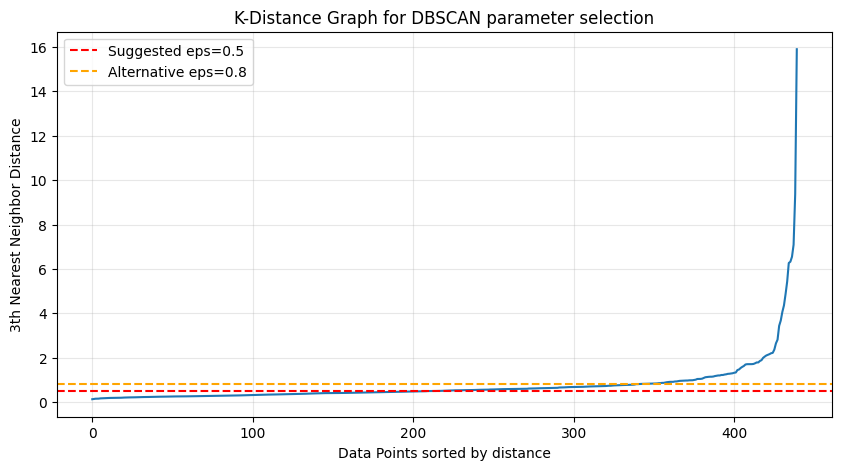

DBSCAN Clustering Results with Different Parameters:
   eps  min_samples  n_clusters  n_noise  silhouette_score
9  1.0            3           2       41          0.416427
4  0.5            5           2      174          0.195811
6  0.8            3           2       62          0.047508
5  0.5           10           2      227         -0.014646
3  0.5            3           6      141         -0.073297
1  0.3            5           2      321         -0.129079
0  0.3            3           6      299         -0.295744
2  0.3           10           1      363         -1.000000
7  0.8            5           1       74         -1.000000
8  0.8           10           1       95         -1.000000

BEST DBSCAN MODEL
eps: 1.0
min_samples: 3.0
Number of clusters: 3
Number of noise points: 41
Silhouette Score: 0.416


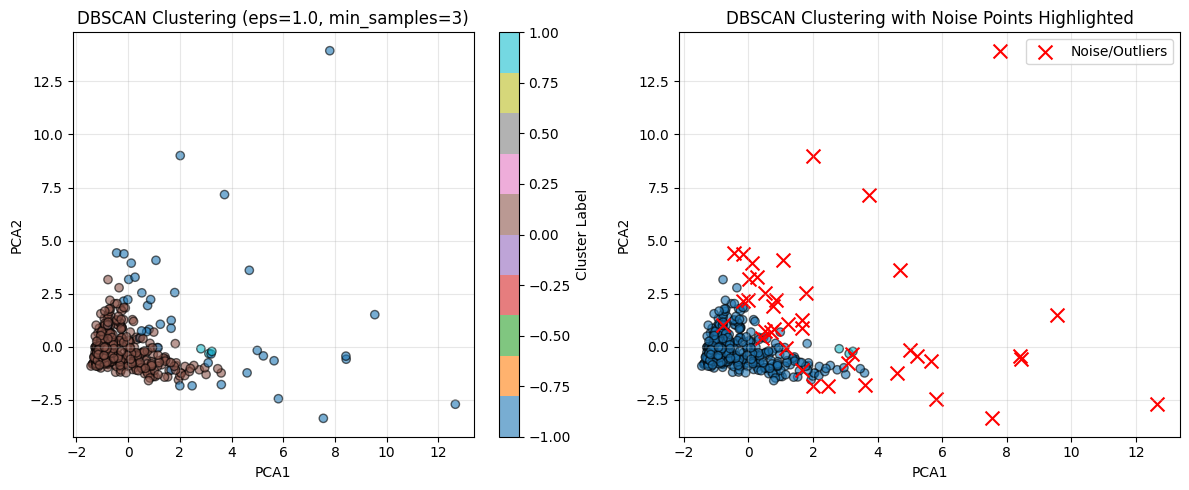

In [77]:
#DBSCAN Clustering
#Cari parameter eps yang optimal
from sklearn.neighbors import NearestNeighbors

#K-distance graph untuk menentukan eps
new_neighbors = NearestNeighbors(n_neighbors=5)
new_neighbors_fit = new_neighbors.fit(X_2_scaled)
new_distances, new_indices = new_neighbors_fit.kneighbors(X_2_scaled)

new_distances = np.sort(new_distances[:, 4], axis=0) #jarak ke tetangga ke-5 untuk setiap titik data
plt.figure(figsize=(10, 5))
plt.plot(new_distances)
plt.xlabel('Data Points sorted by distance')
plt.ylabel('3th Nearest Neighbor Distance')
plt.title('K-Distance Graph for DBSCAN parameter selection')
plt.axhline(y=0.5, color='r', linestyle='--', label='Suggested eps=0.5')
plt.axhline(y=0.8, color='orange', linestyle='--', label='Alternative eps=0.8')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

#DBSCAN dengan berbagai parameter
new_eps_values = [0.3, 0.5, 0.8, 1.0]
new_min_samples_values = [3, 5, 10]

new_results_dbscan = []

for eps in new_eps_values:
    for min_samples in new_min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        labels = dbscan.fit_predict(X_2_scaled)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)

        if n_clusters > 1:
            sil_score = silhouette_score(X_2_scaled, labels)
        else: sil_score = -1  # Tidak valid jika hanya ada 1 cluster

        new_results_dbscan.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters,
            'n_noise': n_noise,
            'silhouette_score': sil_score
        })

new_results_df = pd.DataFrame(new_results_dbscan)
print("DBSCAN Clustering Results with Different Parameters:")
print(new_results_df.sort_values(by='silhouette_score', ascending=False).head(10))

#Best DBSCAN model
new_best_params = new_results_df.loc[new_results_df['silhouette_score'].idxmax()]
dbscan = DBSCAN(eps=new_best_params['eps'], min_samples=int(new_best_params['min_samples']))
new_df['Cluster DBSCAN'] = dbscan.fit_predict(X_2_scaled)

new_n_clusters_dbscan = len(set(new_df['Cluster DBSCAN'])) - (1 if -1 in new_df['Cluster DBSCAN'] else 0)
new_n_noise_dbscan = (new_df['Cluster DBSCAN'] == -1).sum()

print(f"\nBEST DBSCAN MODEL")
print(f"eps: {new_best_params['eps']}")
print(f"min_samples: {new_best_params['min_samples']}")
print(f"Number of clusters: {new_n_clusters_dbscan}")
print(f"Number of noise points: {new_n_noise_dbscan}")
print(f"Silhouette Score: {new_best_params['silhouette_score']:.3f}")

#Visualisasi DBSCAN Clusters
plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(new_df['PCA1'], new_df['PCA2'],
                      c=new_df['Cluster DBSCAN'], cmap='tab10', alpha=0.6, edgecolors='k')
plt.colorbar(scatter, label='Cluster Label')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title(f'DBSCAN Clustering (eps={new_best_params["eps"]}, min_samples={int(new_best_params["min_samples"])})')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
#Highlight noise points
new_normal_points = new_df[new_df['Cluster DBSCAN'] != -1]
new_noise_points = new_df[new_df['Cluster DBSCAN'] == -1]

plt.scatter(new_normal_points['PCA1'], new_normal_points['PCA2'],
            c=new_normal_points['Cluster DBSCAN'], cmap='tab10', alpha=0.6, edgecolors='k')
plt.scatter(new_noise_points['PCA1'], new_noise_points['PCA2'],
            c='red', marker='x', s=100, label='Noise/Outliers')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title('DBSCAN Clustering with Noise Points Highlighted')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Clustering algorithms comparison

Metrics Comparison (better silhouette score, lower Davies-Bouldin score):
K-Means: Silhouette Score = 0.548, Davies-Bouldin Score = 0.928, Clusters = 3
Hierarchical (Ward): Silhouette Score = 0.265, Davies-Bouldin Score = 1.285, Clusters = 3
DBSCAN: Silhouette Score = 0.416, Davies-Bouldin Score = 2.068, Clusters = 3


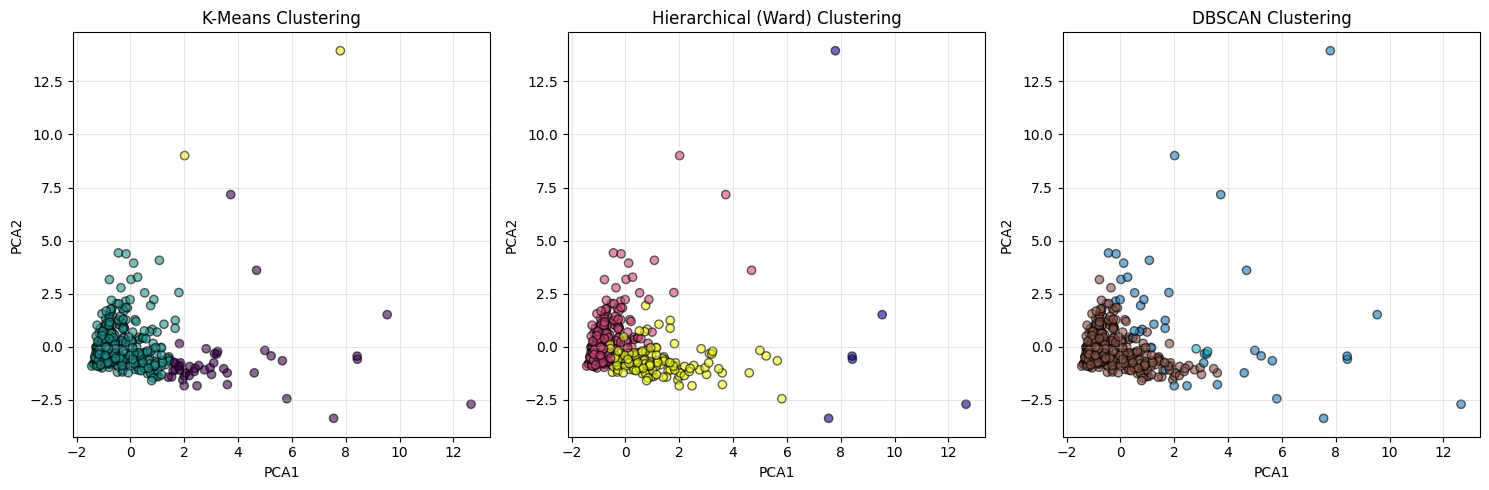


Business Recommendations based on Clustering Results:
Berdasarkan segmentasi yang ditemukan:

Cluster 0 (Fresh & Grocery):
  • - Tawarkan produk segar dan kebutuhan pokok dengan harga kompetitif untuk menarik pelanggan ini.
  • - Fokus pada penawaran yang memberikan nilai tinggi dengan harga terjangkau untuk menarik pelanggan ini agar tetap berbelanja.
  • - Gunakan kampanye pemasaran yang menyoroti kualitas dan kesegaran produk untuk menarik pelanggan ini agar meningkatkan frekuensi belanja mereka.

Cluster 1 (Milk & Detergents_Paper):
  • - Tawarkan produk susu dan kebutuhan rumah tangga dengan harga kompetitif untuk menarik pelanggan ini.
  • - Fokus pada penawaran yang memberikan nilai tinggi dengan harga terjangkau untuk menarik pelanggan ini agar tetap berbelanja.
  • - Gunakan kampanye pemasaran yang menyoroti kualitas dan nilai produk untuk menarik pelanggan ini agar meningkatkan frekuensi belanja mereka.

Cluster 2 (Frozen & Delicassen):
  • - Tawarkan produk beku dan makanan

In [80]:
#Perbandingan dan Evaluasi
from sklearn.metrics import davies_bouldin_score

new_algorithms ={
    'K-Means' : new_df['Cluster KMeans'],
    'Hierarchical (Ward)' : new_df['Cluster Hierarchical'],
    'DBSCAN' : new_df['Cluster DBSCAN']
}

print("Clustering algorithms comparison")
print("\nMetrics Comparison (better silhouette score, lower Davies-Bouldin score):")

for name, labels in new_algorithms.items():
    if len(set(labels)) > 1:
        sil = silhouette_score(X_2_scaled, labels)
        db = davies_bouldin_score(X_2_scaled, labels)
        n_clusters = len(set(labels))
        print(f"{name}: Silhouette Score = {sil:.3f}, Davies-Bouldin Score = {db:.3f}, Clusters = {n_clusters}")
    else:
        print(f"{name}: Only 1 cluster found, metrics not valid.")

#Visualisasi Perbandingan 3 algoritma
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

new_methods = [
    ('K-Means', new_df['Cluster KMeans'], 'viridis'),
    ('Hierarchical (Ward)', new_df['Cluster Hierarchical'], 'plasma'),
    ('DBSCAN', new_df['Cluster DBSCAN'], 'tab10')
]

for idx, (name, labels, cmap) in enumerate(new_methods):
    ax = axes[idx]
    scatter = ax.scatter(new_df['PCA1'], new_df['PCA2'],
                         c=labels, cmap=cmap, alpha=0.6, edgecolors='k')
    ax.set_xlabel('PCA1')
    ax.set_ylabel('PCA2')
    ax.set_title(f"{name} Clustering")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#Rekomendasi untuk Bisnis
print("\nBusiness Recommendations based on Clustering Results:")
print("Berdasarkan segmentasi yang ditemukan:")

segment_strategy = {
    f"Cluster 0 (Fresh & Grocery)": [
        "- Tawarkan produk segar dan kebutuhan pokok dengan harga kompetitif untuk menarik pelanggan ini.",
        "- Fokus pada penawaran yang memberikan nilai tinggi dengan harga terjangkau untuk menarik pelanggan ini agar tetap berbelanja.",
        "- Gunakan kampanye pemasaran yang menyoroti kualitas dan kesegaran produk untuk menarik pelanggan ini agar meningkatkan frekuensi belanja mereka.",
    ],
    f"Cluster 1 (Milk & Detergents_Paper)": [
        "- Tawarkan produk susu dan kebutuhan rumah tangga dengan harga kompetitif untuk menarik pelanggan ini.",
        "- Fokus pada penawaran yang memberikan nilai tinggi dengan harga terjangkau untuk menarik pelanggan ini agar tetap berbelanja.",
        "- Gunakan kampanye pemasaran yang menyoroti kualitas dan nilai produk untuk menarik pelanggan ini agar meningkatkan frekuensi belanja mereka.",
    ],
    f"Cluster 2 (Frozen & Delicassen)": [
        "- Tawarkan produk beku dan makanan khusus dengan harga kompetitif untuk menarik pelanggan ini.",
        "- Fokus pada penawaran yang memberikan nilai tinggi dengan harga terjangkau untuk menarik pelanggan ini agar tetap berbelanja.",
        "- Gunakan kampanye pemasaran yang menyoroti kualitas dan keunikan produk untuk menarik pelanggan ini agar meningkatkan frekuensi belanja mereka.",
    ]
}

for segment, strategy in segment_strategy.items():
    print(f"\n{segment}:")
    for s in strategy:
        print(f"  • {s}")

In [88]:
kmeans_log = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels_log = kmeans_log.fit_predict(X_2_log_scaled)

print(pd.Series(labels_log).value_counts())

0    252
1    188
Name: count, dtype: int64


In [90]:
centers_original = np.expm1(
    scaler.inverse_transform(
        kmeans_log.cluster_centers_
    )
)

print(
    pd.DataFrame(
        centers_original,
        columns=features
    )
)

         Fresh         Milk       Grocery       Frozen  Detergents_Paper  \
0  8580.591769  1753.697507   2274.383823  2063.830219        287.370418   
1  4013.880833  8061.572603  12051.066066   953.532640       4035.601840   

    Delicassen  
0   649.350279  
1  1022.085648  


In [92]:
pd.crosstab(
    new_df['Channel'],
    labels_log,
    margins=True
)

col_0,0,1,All
Channel,,,
1,244,54,298
2,8,134,142
All,252,188,440


K-Means Clustering on Moons Dataset: Number of clusters found: 2, Silhouette Score: 0.495
DBSCAN Clustering Results on Moons Dataset:
   eps  min_samples  n_clusters  n_noise  silhouette_score
0  0.3            3           2        0          0.386026
1  0.3            5           2        0          0.386026
3  0.5            3           2        0          0.386026
4  0.5            5           2        0          0.386026
5  0.5           10           2        0          0.386026
2  0.3           10           2        2          0.189898
6  0.8            3           1        0         -1.000000
7  0.8            5           1        0         -1.000000
8  0.8           10           1        0         -1.000000

Best DBSCAN parameters for Moons Dataset: eps=0.3, min_samples=3
Number of clusters found: 2
Silhouette Score: 0.386


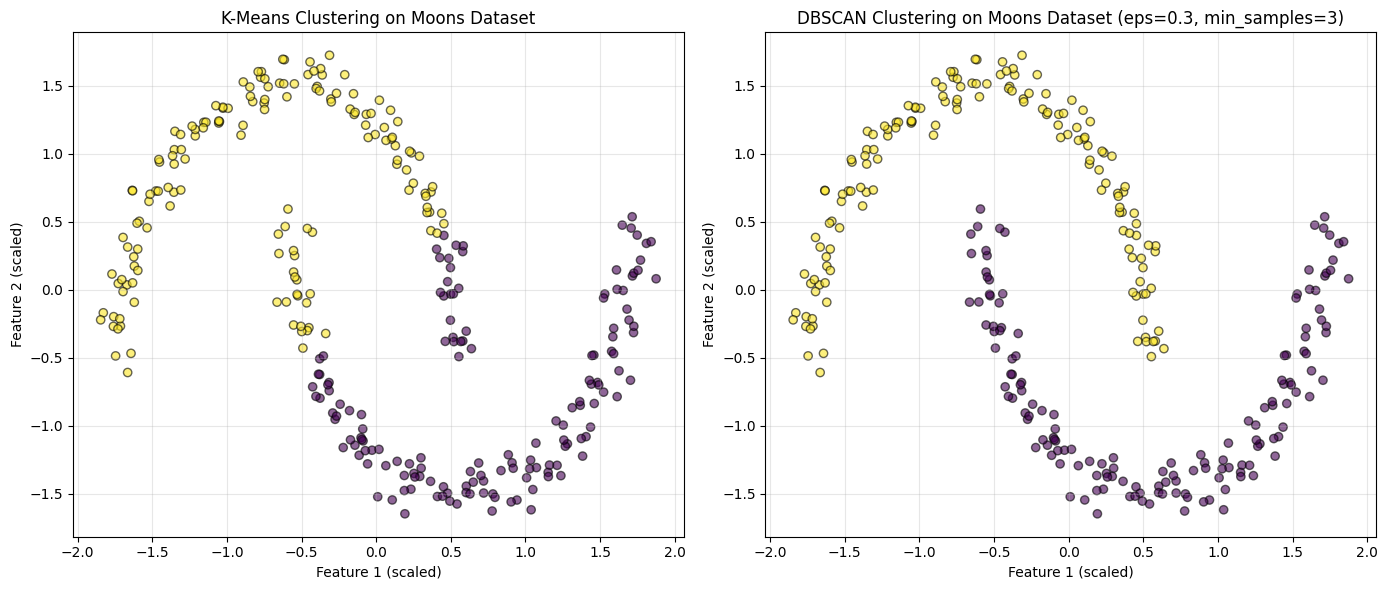

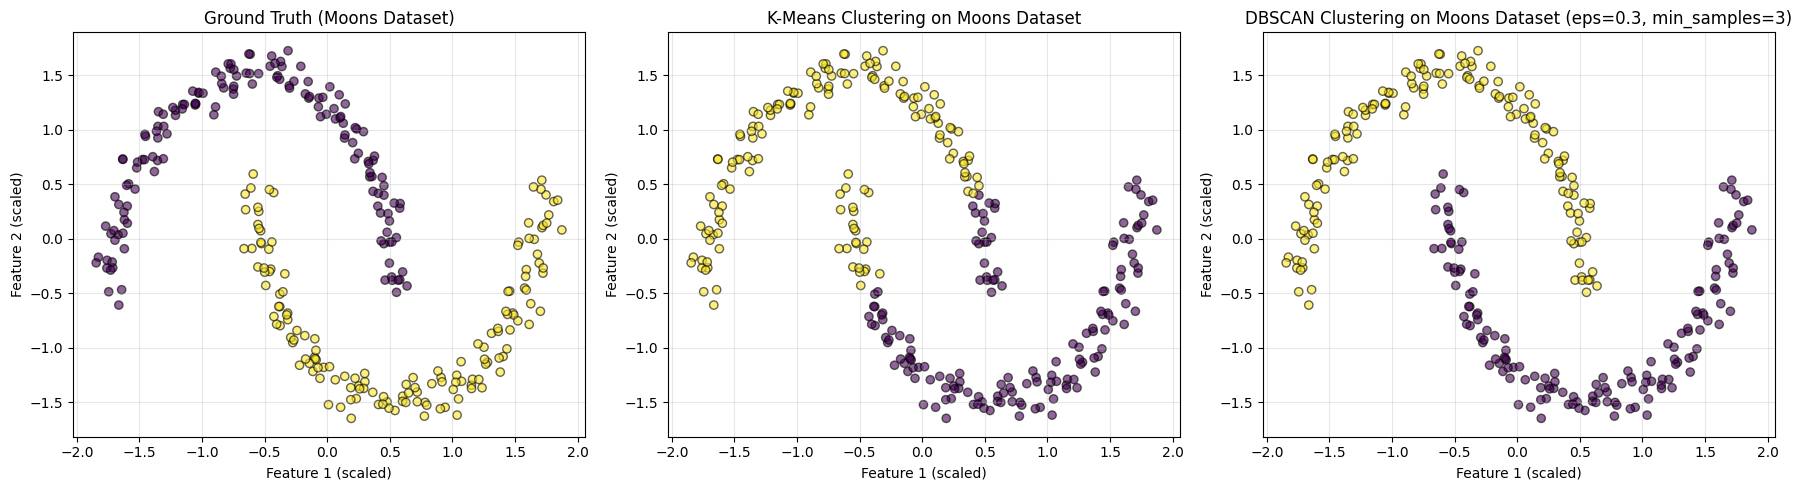

Adjusted Rand Index for K-Means: 0.470
Adjusted Rand Index for DBSCAN: 1.000


In [97]:
#Perbandingan DBSCAN vs K-Means pada data bentuk non-sperikal (buat synthetic data dengan make_moons atau make_circles)
from sklearn.datasets import make_moons
X_moons, y_moons = make_moons(n_samples=300, noise=0.05, random_state=42)
#Scaling data
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)
#K-Means Clustering
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_kmeans_moons = kmeans_moons.fit_predict(X_moons_scaled)
print(f"K-Means Clustering on Moons Dataset: Number of clusters found: {len(set(labels_kmeans_moons))}, Silhouette Score: {silhouette_score(X_moons_scaled, labels_kmeans_moons):.3f}")

#DBSCAN Clustering
eps_moons = [0.3, 0.5, 0.8]
min_samples_moons = [3, 5, 10]
results_dbscan_moons = []

for eps in eps_moons:
    for min_samples in min_samples_moons:
        dbscan_moons = DBSCAN(eps=eps, min_samples=min_samples)
        labels_dbscan_moons = dbscan_moons.fit_predict(X_moons_scaled)
        n_clusters_dbscan = len(set(labels_dbscan_moons)) - (1 if -1 in labels_dbscan_moons else 0)
        n_noise_dbscan = list(labels_dbscan_moons).count(-1)

        if n_clusters_dbscan > 1:
            sil_score_dbscan = silhouette_score(X_moons_scaled, labels_dbscan_moons)
        else: sil_score_dbscan = -1

        results_dbscan_moons.append({
            'eps': eps,
            'min_samples': min_samples,
            'n_clusters': n_clusters_dbscan,
            'n_noise': n_noise_dbscan,
            'silhouette_score': sil_score_dbscan
        })

results_dbscan_moons_df = pd.DataFrame(results_dbscan_moons)
print("DBSCAN Clustering Results on Moons Dataset:")
print(results_dbscan_moons_df.sort_values(by='silhouette_score', ascending=False).head(10))
best_dbscan_moons_params = results_dbscan_moons_df.loc[results_dbscan_moons_df['silhouette_score'].idxmax()]
dbscan_moons_best = DBSCAN(eps=best_dbscan_moons_params['eps'], min_samples=int(best_dbscan_moons_params['min_samples']))
labels_dbscan_moons_best = dbscan_moons_best.fit_predict(X_moons_scaled)
print(f"\nBest DBSCAN parameters for Moons Dataset: eps={best_dbscan_moons_params['eps']}, min_samples={int(best_dbscan_moons_params['min_samples'])}")
print(f"Number of clusters found: {len(set(labels_dbscan_moons_best)) - (1 if -1 in labels_dbscan_moons_best else 0)}")
print(f"Silhouette Score: {best_dbscan_moons_params['silhouette_score']:.3f}")

#Visualisasi Perbandingan K-Means vs DBSCAN pada Moons Dataset
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=labels_kmeans_moons, cmap='viridis', alpha=0.6, edgecolors='k')
axes[0].set_title('K-Means Clustering on Moons Dataset')
axes[0].set_xlabel('Feature 1 (scaled)')
axes[0].set_ylabel('Feature 2 (scaled)')
axes[0].grid(alpha=0.3)
axes[1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=labels_dbscan_moons_best, cmap='viridis', alpha=0.6, edgecolors='k')
axes[1].set_title(f"DBSCAN Clustering on Moons Dataset (eps={best_dbscan_moons_params['eps']}, min_samples={int(best_dbscan_moons_params['min_samples'])})")
axes[1].set_xlabel('Feature 1 (scaled)')
axes[1].set_ylabel('Feature 2 (scaled)')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

#ground truth vs K-Means vs DBSCAN
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=y_moons, cmap='viridis', alpha=0.6, edgecolors='k')
axes[0].set_title('Ground Truth (Moons Dataset)')
axes[0].set_xlabel('Feature 1 (scaled)')
axes[0].set_ylabel('Feature 2 (scaled)')
axes[0].grid(alpha=0.3)
axes[1].scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1],
                c=labels_kmeans_moons, cmap='viridis', alpha=0.6, edgecolors='k')
axes[1].set_title('K-Means Clustering on Moons Dataset')
axes[1].set_xlabel('Feature 1 (scaled)')
axes[1].set_ylabel('Feature 2 (scaled)')
axes[1].grid(alpha=0.3)
axes[2].scatter(X_moons_scaled[:, 0], X_moons_scaled[:,
                1], c=labels_dbscan_moons_best, cmap='viridis', alpha=0.6, edgecolors='k')
axes[2].set_title(f"DBSCAN Clustering on Moons Dataset (eps={best_dbscan_moons_params['eps']}, min_samples={int(best_dbscan_moons_params['min_samples'])})")
axes[2].set_xlabel('Feature 1 (scaled)')
axes[2].set_ylabel('Feature 2 (scaled)')
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.show()

#accuracy dengan ground truth
from sklearn.metrics import adjusted_rand_score
ari_kmeans = adjusted_rand_score(y_moons, labels_kmeans_moons)
ari_dbscan = adjusted_rand_score(y_moons, labels_dbscan_moons_best)
print(f"Adjusted Rand Index for K-Means: {ari_kmeans:.3f}")
print(f"Adjusted Rand Index for DBSCAN: {ari_dbscan:.3f}")


In [122]:
#Mencoba plotly
from sklearn.decomposition import  PCA

pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_2_scaled)

new_df['PCA1 3d'] = X_3d[:, 0]
new_df['PCA2 3d'] = X_3d[:, 1]
new_df['PCA3 3d'] = X_3d[:, 2]

import plotly.express as px
import plotly.io as pio

fig = px.scatter_3d(
    new_df,
    x='PCA1 3d',
    y='PCA2 3d',
    z='PCA3 3d',
    color='Cluster KMeans',
    title='3D PCA Visualization of K-Means Clusters',
    opacity=0.7
)

pio.renderers.default = 'browser' # Sesuaikan dengan lingkungan Anda (e.g., 'browser', 'notebook', 'iframe')

fig.show()

In [120]:
import nbformat
print(f"Nbformat version : {nbformat.__version__}")
import notebook
print(f"Notebook version : {notebook.__version__}")
import IPython
print(f"IPython version : {IPython.__version__}")
import plotly
print(f"Plotly version : {plotly.__version__}")
print(pio.renderers)

Nbformat version : 5.10.4
Notebook version : 7.5.7
IPython version : 9.14.1
Plotly version : 6.8.0
Renderers configuration
-----------------------
    Default renderer: 'browser'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [106]:
import sys
print(sys.executable)

c:\Program Files\Python312\python.exe


In [118]:
fig.write_html(
    "dashboard_clustering_3d.html",
    auto_open=True
)

In [123]:
import nbformat
print(nbformat)
print(nbformat.__file__)

<module 'nbformat' from 'C:\\Users\\abrah\\AppData\\Roaming\\Python\\Python312\\site-packages\\nbformat\\__init__.py'>
C:\Users\abrah\AppData\Roaming\Python\Python312\site-packages\nbformat\__init__.py


In [124]:
import plotly.express as px

df = px.data.iris()

fig = px.scatter(
    df,
    x="sepal_width",
    y="sepal_length"
)

fig.show()

In [125]:
import plotly.io as pio

pio.renderers.default = "json"

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [126]:
import plotly.io as pio

pio.renderers.default = "png"

fig.show()

ValueError: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido


In [127]:
import plotly.io as pio
print(pio.renderers)

Renderers configuration
-----------------------
    Default renderer: 'png'
    Available renderers:
        ['plotly_mimetype', 'jupyterlab', 'nteract', 'vscode',
         'notebook', 'notebook_connected', 'kaggle', 'azure', 'colab',
         'cocalc', 'databricks', 'json', 'png', 'jpeg', 'jpg', 'svg',
         'pdf', 'browser', 'firefox', 'chrome', 'chromium', 'iframe',
         'iframe_connected', 'sphinx_gallery', 'sphinx_gallery_png']



In [128]:
fig.show(renderer="plotly_mimetype")

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed